|컬럼명| 정의 | 타입 | 비고 |
|---|---|---|---|
| `Channel` | 고객채널 | 명목형 | 1 : horeca(호텔/레스토랑/카페), 2 : Retail(소매유통) |
| `Region` | 고객지역 | 명목형 | 1: Lisbon, 2 : Oporto, 3 : Other |
| `Fresh` | 신선식품 연간 구매액 | 연속형 | |
| `Milk` | 유제품 연간 구매액 | 연속형 | |
| `Grocery` | 식료품 연간 구매액 | 연속형 | |
| `Frozen` | 냉동식품 연간 구매액 | 연속형 | |
| `Detergents_Paper` | 세제 및 종이류 연간 구매액 | 연속형 | |
| `Delicassen` | 즉석/가공식품 연간 구매액 | 연속형 | |

# **Wholesales customers 비지도분석 파이프라인**

## #0. 라이브러리 불러오기

In [2]:
from helper import *
import pandas as pd
import numpy as np
from IPython.display import Markdown, display

## #1. 데이터 품질 점검 및 데이터 전처리

### **1)** 데이터 구조 점검 <br>
#### **1-1** 데이터 불러오기 & 크기확인

In [3]:
# 데이터 불러오기
origin = pd.read_csv(r'./Wholesale customers data.csv', encoding='utf-8')
display(origin.head())

# 데이터 크기 확인
print('데이터 크기 : ', origin.shape)

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


데이터 크기 :  (440, 8)


#### **1-2** 데이터타입 점검

In [4]:
origin.info()

<class 'pandas.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


#### **1-3** 데이터 타입 변환
- `Channel`, `Region` 컬럼은 명목형으로 변환
- 채널 및 컬럼은 연속형으로 되어있으나, 실질적으로는 명목형 변수
- `Channel` = 1.**Horeca** /  2.**Retail**
- `Region` = 1.**Lisbon** / 2.**Oporto** / 3.**Other Region**

In [5]:
df = my_qtcheck.set_type(origin, as_category=['Channel', 'Region'])

<class 'pandas.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   Channel           440 non-null    category
 1   Region            440 non-null    category
 2   Fresh             440 non-null    int64   
 3   Milk              440 non-null    int64   
 4   Grocery           440 non-null    int64   
 5   Frozen            440 non-null    int64   
 6   Detergents_Paper  440 non-null    int64   
 7   Delicassen        440 non-null    int64   
dtypes: category(2), int64(6)
memory usage: 21.7 KB


#### **1-4** 데이터 중복 확인
- 중복된 행의 수는 0건

In [6]:
my_qtcheck.check_duplicates(df)

중복된 행의 수: 0


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185
...,...,...,...,...,...,...,...,...
435,1,3,29703,12051,16027,13135,182,2204
436,1,3,39228,1431,764,4510,93,2346
437,2,3,14531,15488,30243,437,14841,1867
438,1,3,10290,1981,2232,1038,168,2125


#### 1-5 형식, 표기, 단위, 점검 (1) - 연속형 변수

In [7]:
# 연속형 변수 목록 리스트 정의
num_cols = my_qtcheck.get_number_column_names(df)

minmax = []     # 최소값, 최대값을 저장할 리스트

for i in num_cols:          # 연속형 변수 반복문
    min_value= df[i].min()  # 최소값
    max_value = df[i].max() # 최대값
    # 반복문에 대한 최소값, 최대값 리스트 추가
    minmax.append({'min' : min_value, 'max' : max_value})   

# 최소값과 최대값을 데이터프레임으로 출력
minmax_df = pd.DataFrame(minmax, index=num_cols)
minmax_df

,min,max
Fresh,3,112151
Milk,55,73498
Grocery,3,92780
Frozen,25,60869
Detergents_Paper,3,40827
Delicassen,3,47943


#### 1-6 형식, 표기, 단위, 점검 (2) - 명목형 변수

In [8]:
# 명목형 변수 컬럼 리스트 목록
cat_cols = my_qtcheck.get_categorical_column_names(df)

# 명목형 변수에 대한 반복문
for c in cat_cols:
    count = df[c].value_counts()    # 명목형 컬럼 카운트
    display(count)                  # 카운트 출력결과


Channel
1    298
2    142
Name: count, dtype: int64

Region
3    316
1     77
2     47
Name: count, dtype: int64

### **2)** 데이터 품질 점검

#### **2-1** 데이터 결측치 확인
- 데이터 결측치 0건

In [9]:
my_qtcheck.check_missing_values(df)

,Missing Count,Missing Ratio (%)
Channel,0,0.0
Region,0,0.0
Fresh,0,0.0
Milk,0,0.0
Grocery,0,0.0
Frozen,0,0.0
Detergents_Paper,0,0.0
Delicassen,0,0.0


#### 2-2 품질 점검 데이터셋 저장

In [10]:
df.to_excel('Wholesale customers_qtcheck.xlsx', index=False)

### 3) 기술 통계량
#### 3-1 연속형 변수의 기술 통계량

In [11]:
num_desc = my_qtcheck.numerical_summary(df,
                                               save_path='Wholesale customers_numerical_summary.xlsx')
num_desc.T

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.0,440.0,440.0,440.0,440.0,440.0
mean,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,3.0,55.0,3.0,25.0,3.0,3.0
25%,3127.75,1533.0,2153.0,742.25,256.75,408.25
50%,8504.0,3627.0,4755.5,1526.0,816.5,965.5
75%,16933.75,7190.25,10655.75,3554.25,3922.0,1820.25
max,112151.0,73498.0,92780.0,60869.0,40827.0,47943.0
rel_diff,0.411136,0.598088,0.672017,1.013061,2.529079,0.579358
rdiff_flag,diff,large_diff,large_diff,large_diff,large_diff,large_diff


#### 3-2 범주형 변수의 기술 통계량

In [12]:
cat_desc = my_qtcheck.categorical_summary(df)
cat_desc

📊 컬럼 'Channel'의 value_counts():


,count
Channel,
1,298
2,142


📊 컬럼 'Region'의 value_counts():


,count
Region,
1,77
2,47
3,316


,Channel,Region
count,440,440
unique,2,3
top,1,3
freq,298,316


#### 3-3 불필요한 컬럼 삭제 후, 저장

> `Region` (지역 -Lisbon:1, Oporto:2, Other:3) 고객 분포는 **Other 316명(약 71.8%)**, **Lisbon 77명(약 17.5%)**, **Oporto 47명(약 10.7%)** 순으로 **Other**로 크게 쏠려있어 집단비교가 어려워 분석대상에서 제거합니다.

In [13]:
df = df.drop(columns='Region')

# 최종 명목형 변수 기술통계량 저장
cat_desc = my_qtcheck.categorical_summary(df, 
                               save_path='Wholesale customers_categorical_summary.xlsx')

cat_desc

📊 컬럼 'Channel'의 value_counts():


,count
Channel,
1,298
2,142


,Channel
count,440
unique,2
top,1
freq,298


#### 📊 데이터 품질점검 종합 해석
##### 1. 데이터 기본 구조 및 품질
- 전체 데이터는 **440개 고객, 8개 컬럼**으로 구성되어 있습니다. 연속형 변수 6개와 명목형 변수 2개가 포함.
- 모든 변수에서 **결측치와 중복 행이 0건**으로 확인되어 고유성 확인 되었음.
- `Channel`, `Region`은 고객 유형과 지역을 나타내는 범주형 변수이므로 category 타입으로 변환.
##### 2. 데이터 중심수준
- 연속형 변수컬럼은 `Fresh` **12,000.30**, `Grocery` **7,951.28**, `Milk` **5,796.27**, `Frozen` **3,071.93**, `Detergents_Paper` **2,881.49**, `Delicassen` **1,524.87** 순임.
- 모든 연속형 변수 평균이 중앙값보다 높다. 예를 들어 `Fresh`는 평균 **12,000.30**, 중앙값 **8,504**, `Delicassen`은 평균 **1,524.87**, 중앙값 **965.5**임.
- 이는 일부 고객의 구매액이 매우 커서 평균이 상승한 결과이다.
##### 3. 데이터 퍼짐과 안정성
- 표준편차가 평균과 비슷하거나 더 큰 변수들이 많아 고객별 구매액 차이가 크다.
- 따라서 구매액 분포는 전반적으로 안정적이라고 보기 어렵고, 특히 `Delicassen`, `Detergents_Paper`, `Frozen`의 고객별 이질성이 큽니다.
- 사분위수와 최대값의 차이도 큽니다. 예를 들어 `Fresh`의 75% 지점은 **16,933.75**인 반면 최대값은 **112,151**이며, `Delicassen`의 75% 지점은 **1,820.25**인 반면 최대값은 **47,943**입니다.
- 추후 군집분석이나 거리 기반 분석을 수행할 때 변수별 규모 차이와 극단값의 영향을 줄이기 위해 로그 변환 및 표준화를 검토할 필요가 있다.
##### 4. 이상치 및 분포 형태
- 모든 연속형 변수에서 왜도가 양수이고 `right tail`로 판정되어, 대부분의 고객은 상대적으로 낮은 구매액에 몰리고 소수의 고객만 매우 높은 구매액을 갖는 **우측 꼬리 분포**이다.
- 왜도는 `Delicassen` **11.15**, `Frozen` **5.91**, `Milk` **4.05** 순으로 크게 나타난다. 특히 `Delicassen`은 극단적인 비대칭성이 확인됩니다.
- IQR 기준 상한 이상치는 모든 변수에서 확인되며, 비율은 `Fresh` **4.55%**, `Milk` **6.36%**, `Grocery` **5.45%**, `Frozen` **9.77%**, `Detergents_Paper` **6.82%**, `Delicassen` **6.14%**이다.
- 하한 이상치는 없고 이상치는 모두 높은 구매액을 가진 고객에서 발생합니다. 이 값들은 오류값이 아니라 대형 고객의 실제 구매 특성을 반영할 수 있는 실재데이터로 일괄 삭제하기보다 로그 변환, 스케일링 또는 군집 결과 비교를 통해 처리한다.
##### 5. 범주형 변수 분포 및 `Region` 제외
- `Channel`은 1번 채널 **298명(약 67.7%)**, 2번 채널 **142명(약 32.3%)**으로 구성되어 1번 채널 고객이 더 많지만 두 범주가 모두 충분히 존재한다.
- `Region`은 3번 지역 **316명(약 71.8%)**, 1번 지역 **77명(약 17.5%)**, 2번 지역 **47명(약 10.7%)**으로 분포가 크게 불균형이다.
- 특히 3번 지역에 고객이 집중되어 지역별 집단 비교나 지역 특성 기반 군집 해석이 `Other`에 왜곡될 가능성이 있다. 따라서 본 분석에서는 `Region`을 제외하고, 고객 구매 패턴과 `Channel` 중심으로 분석을 진행한다.
##### 6. 전처리 방향
- 구매액 변수는 모두 우측 왜도와 고액 이상치를 가지므로, 분석 전에 **로그 변환(`log1p`)과 표준화**를 적용하는 것이 적절.
- 범주형 변수인 `Channel`은 연속형 거리 계산에 직접 사용하지 않고, 분석 목적에 따라 원-핫 인코딩하거나 군집 결과를 해석하는 보조 변수로 활용한다.
- 최종적으로 데이터 품질 문제는 발견되지 않았지만, 분포의 비대칭성과 변수 간 규모 차이가 주요 분석 위험요인으로 확인됨.

## #2. 탐색적 데이터분석 (EDA)

### 1) 준비작업
#### 1-1 변수 유형 분류

In [14]:
target = 'Channel'
target_is_continuous = False

if target_is_continuous:
    num_cols.remove(target)

exclude_cols = 'Region'

print('종속 변수 : ', target)
print('종속 변수 유형 : ' + ('연속형' if target_is_continuous else '범주형'))
print('연속형 : ', num_cols)
print('제외된 변수 : ', exclude_cols)

종속 변수 :  Channel
종속 변수 유형 : 범주형
연속형 :  ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
제외된 변수 :  Region


#### 1-2 컬럼 의미를 정리한 딕셔너리

In [15]:
column_means = {
    'Channel' : '고객 채널',
    'Region' : '고객 지역',
    'Fresh' : '신선 식품에 대한 연간 지출액',
    'Milk' : '유제품에 대한 연간 지출액', 
    'Grocery' : '식료품에 대한 연간 지출액', 
    'Frozen' : '냉동 식품에 대한 연간 지출액',
    'Detergents_Paper' : '세제 및 종이 제품에 대한 연간 지출액', 
    'Delicassen' : '조리 식품에 대한 연간 지출액'
}

#### 1-3 EDA 범위 정리 - ppt

### 2) 단변량 분석
#### 2-1 명목형 종속변수에 대한 단변량 분석 

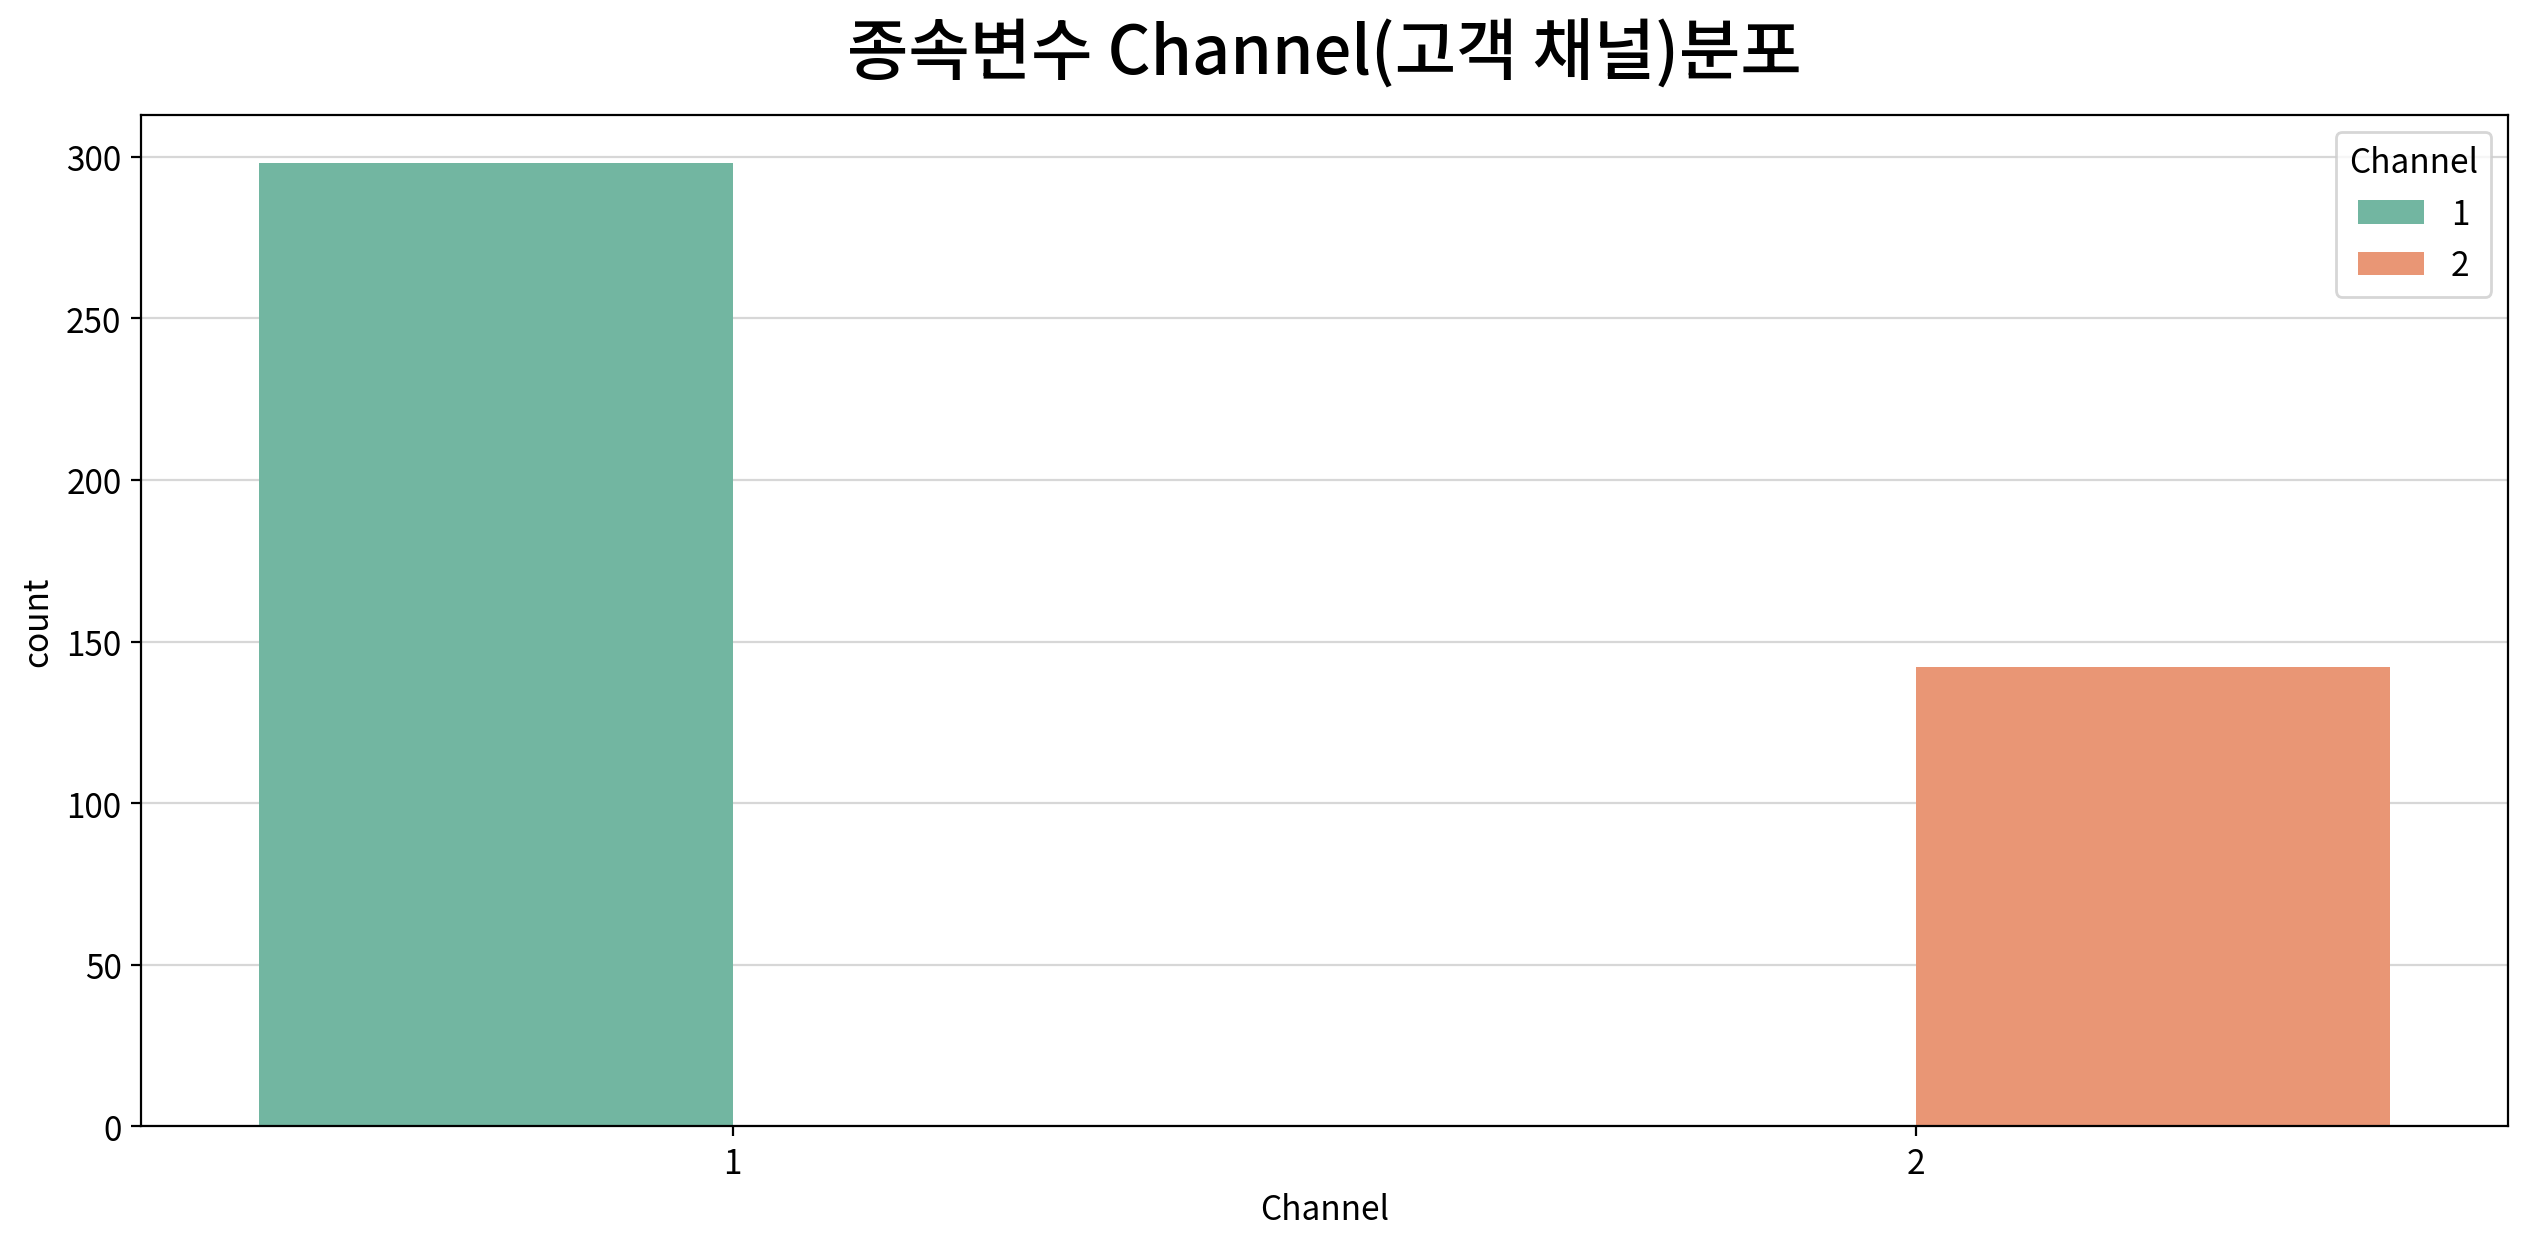

,count,unique,top,freq
Channel,440,2,1,298


,빈도,비율
Channel,,
1,298,0.677273
2,142,0.322727


In [16]:
my_plot.countplot(data=df, x=target, hue=df[target], palette='Set2',
                  title = f'종속변수 {target}({column_means[target]})분포')

display(cat_desc[[target]].T)

# 빈도표 생성
freq = df[target].value_counts().rename('빈도').to_frame()
freq['비율'] = df[target].value_counts(normalize=True)
display(freq)

#### 2-2 연속형 독립변수에 대한 단변량 분석 

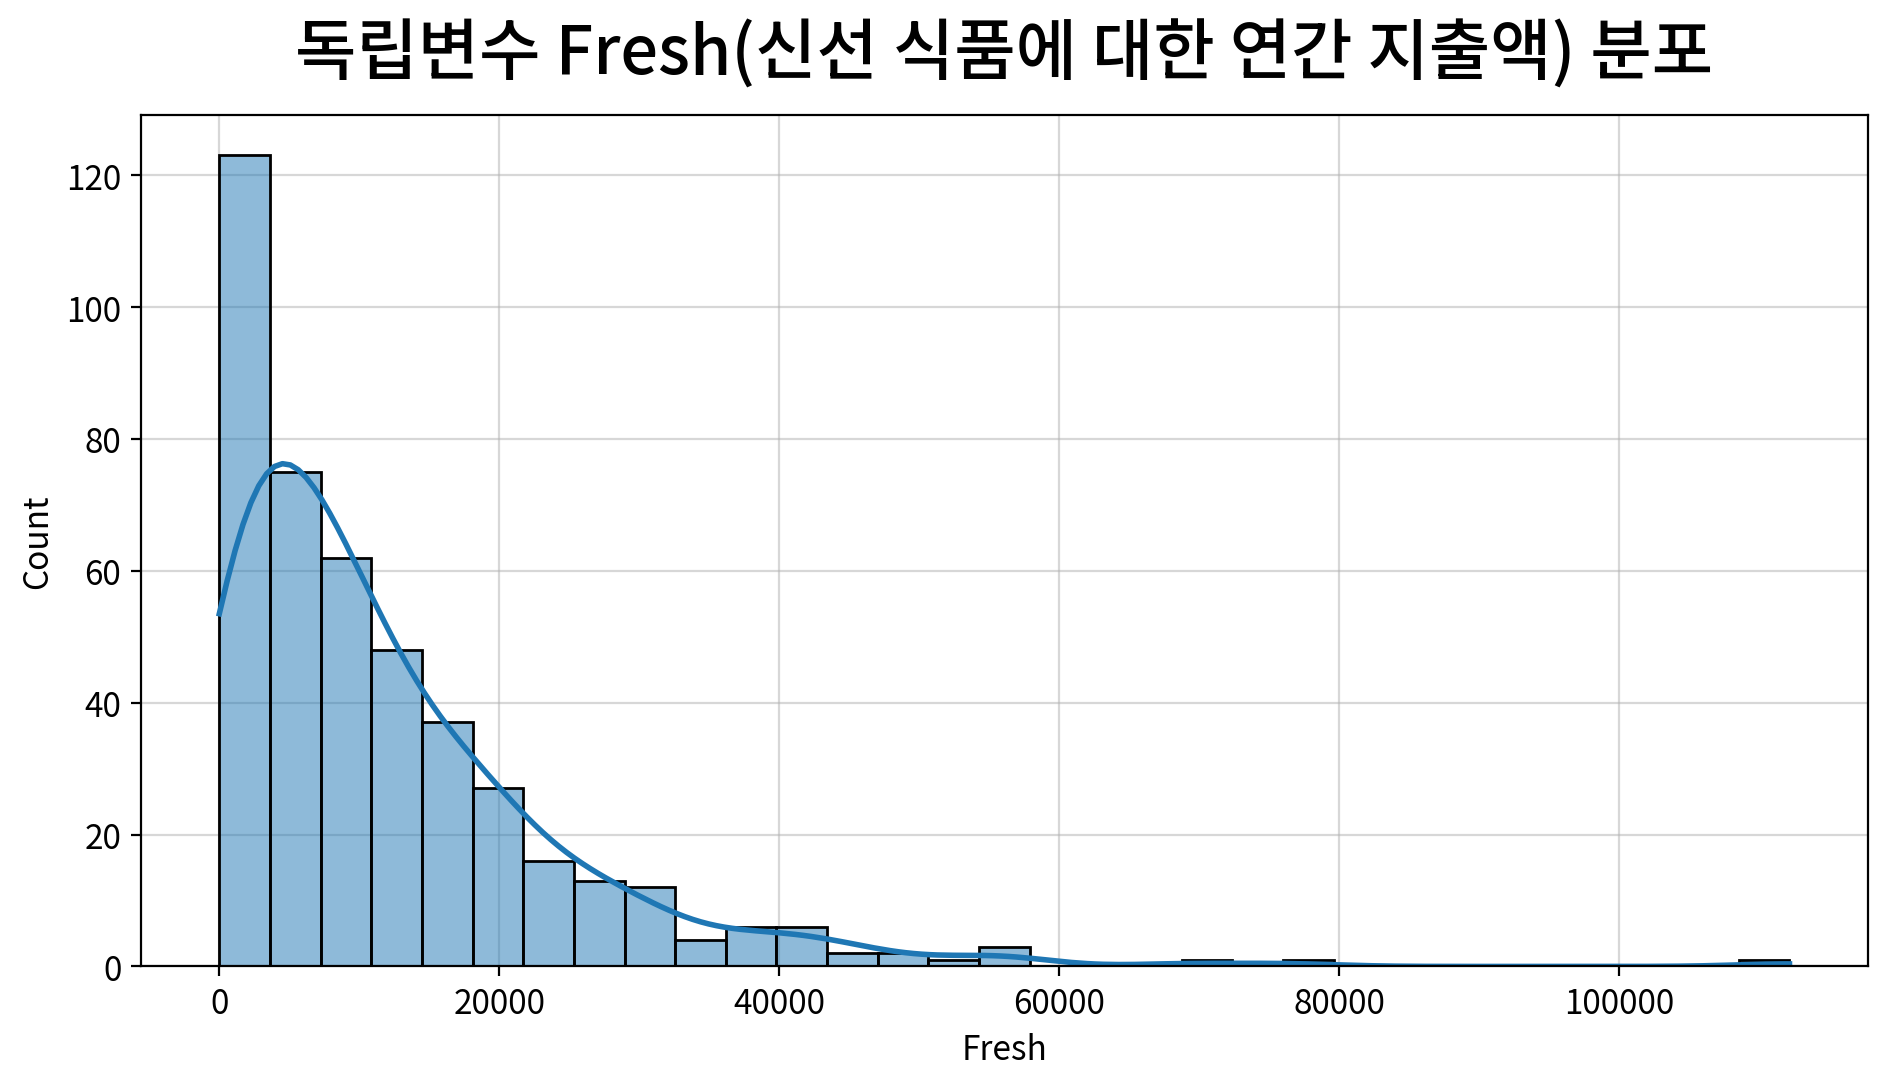

,Fresh
count,440.0
mean,12000.297727
std,12647.328865
min,3.0
25%,3127.75
50%,8504.0
75%,16933.75
max,112151.0
rel_diff,0.411136
rdiff_flag,diff


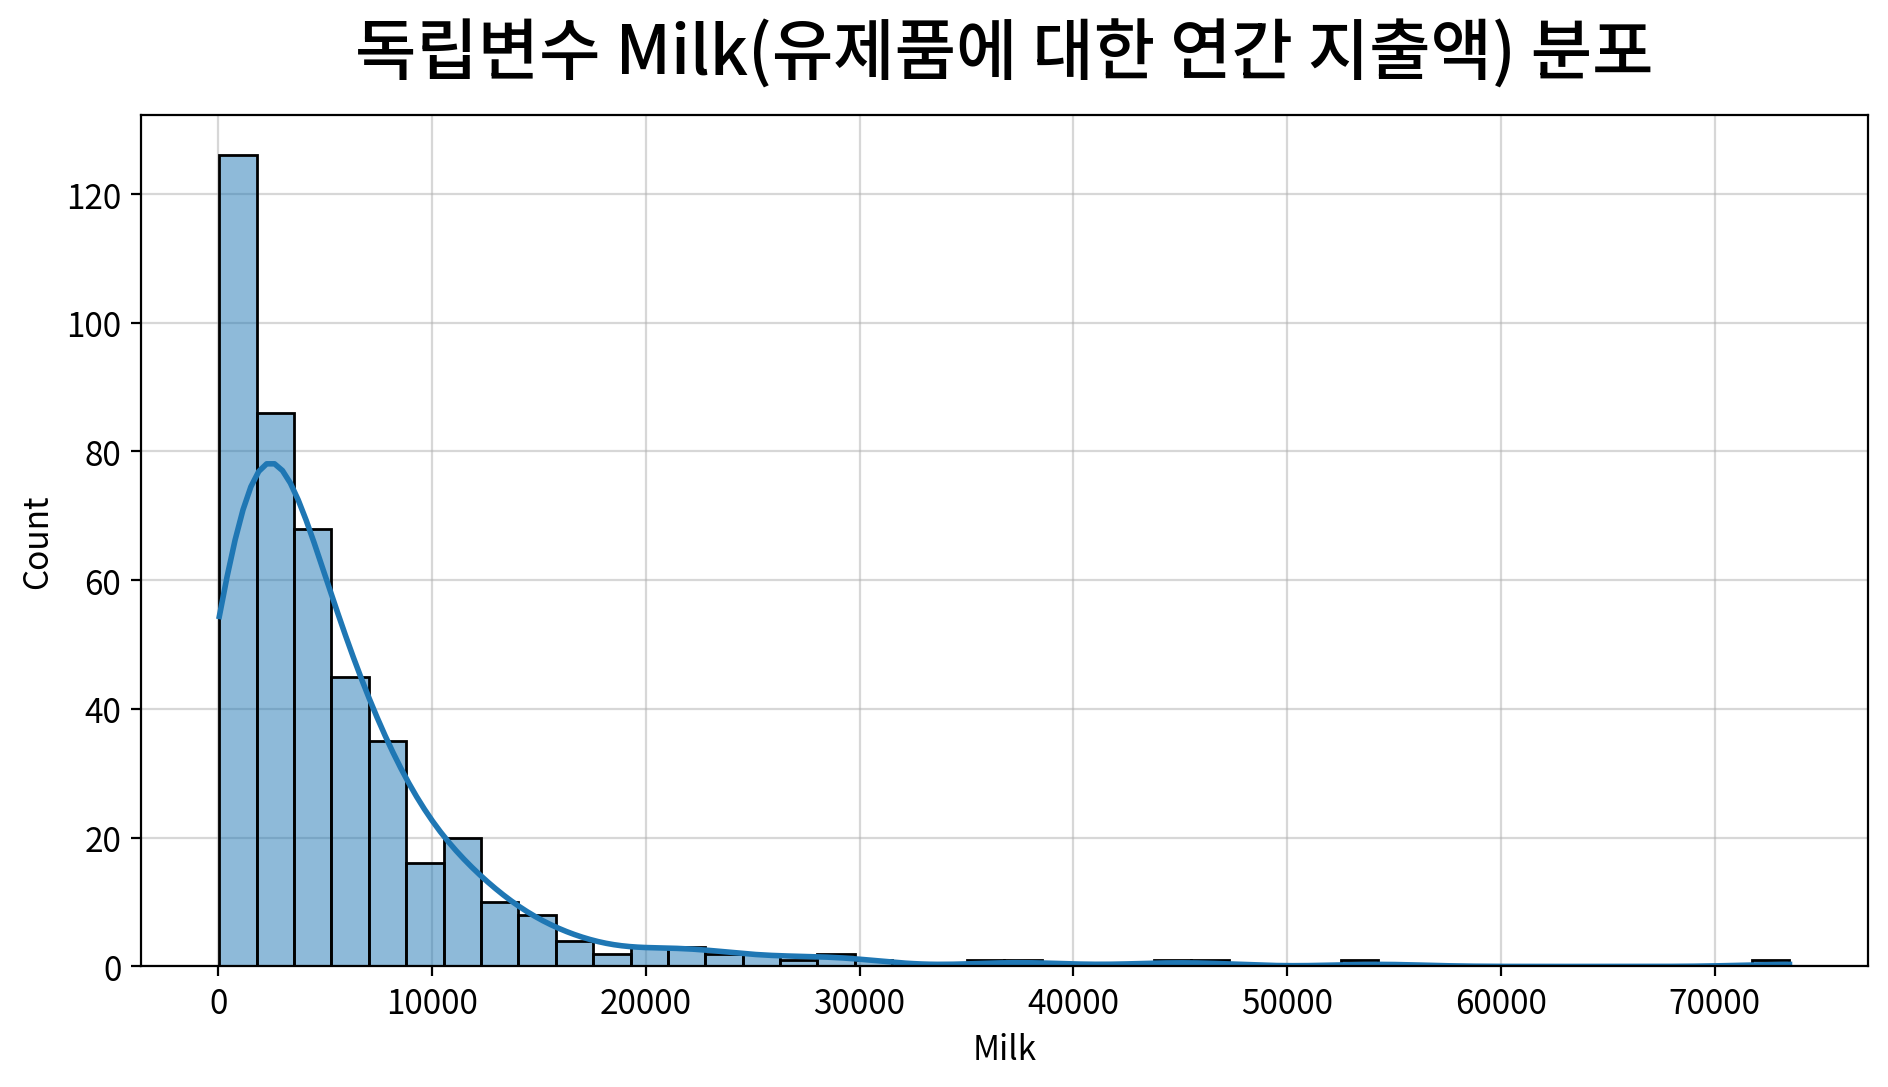

,Milk
count,440.0
mean,5796.265909
std,7380.377175
min,55.0
25%,1533.0
50%,3627.0
75%,7190.25
max,73498.0
rel_diff,0.598088
rdiff_flag,large_diff


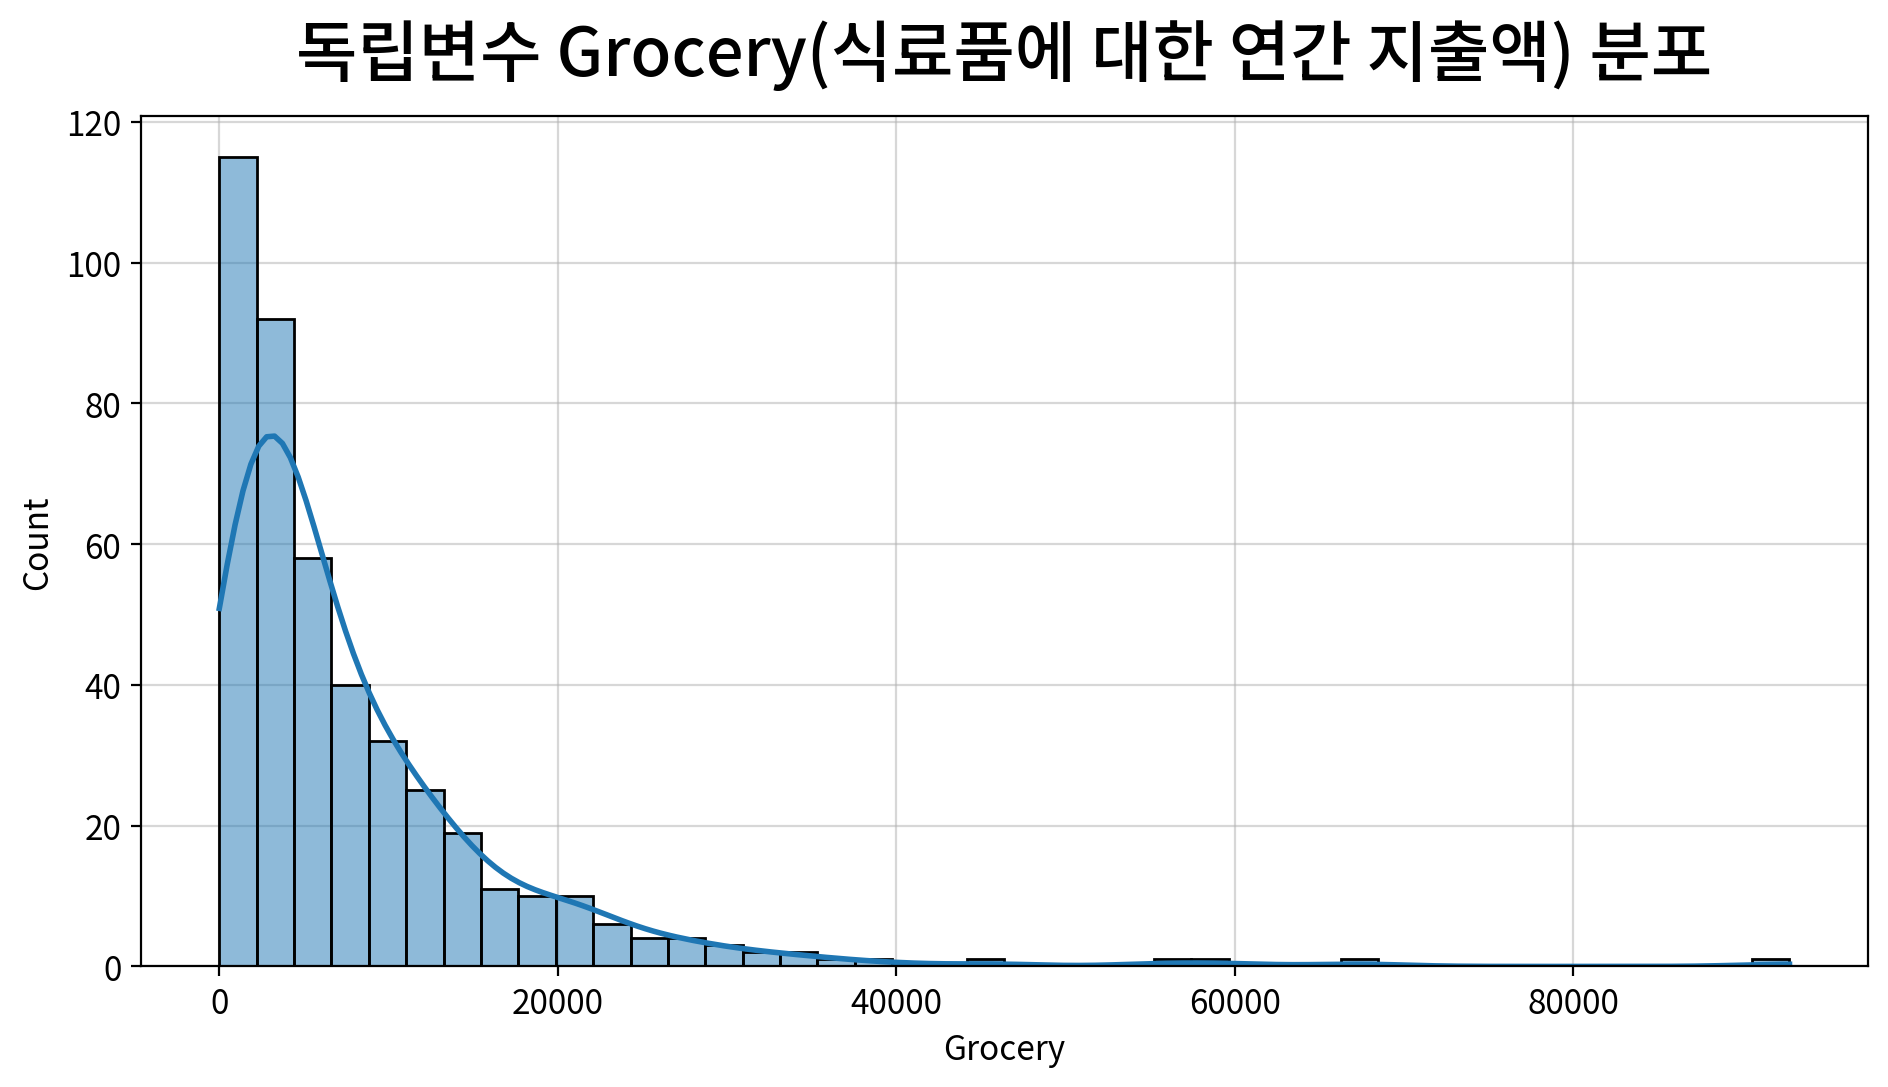

,Grocery
count,440.0
mean,7951.277273
std,9503.162829
min,3.0
25%,2153.0
50%,4755.5
75%,10655.75
max,92780.0
rel_diff,0.672017
rdiff_flag,large_diff


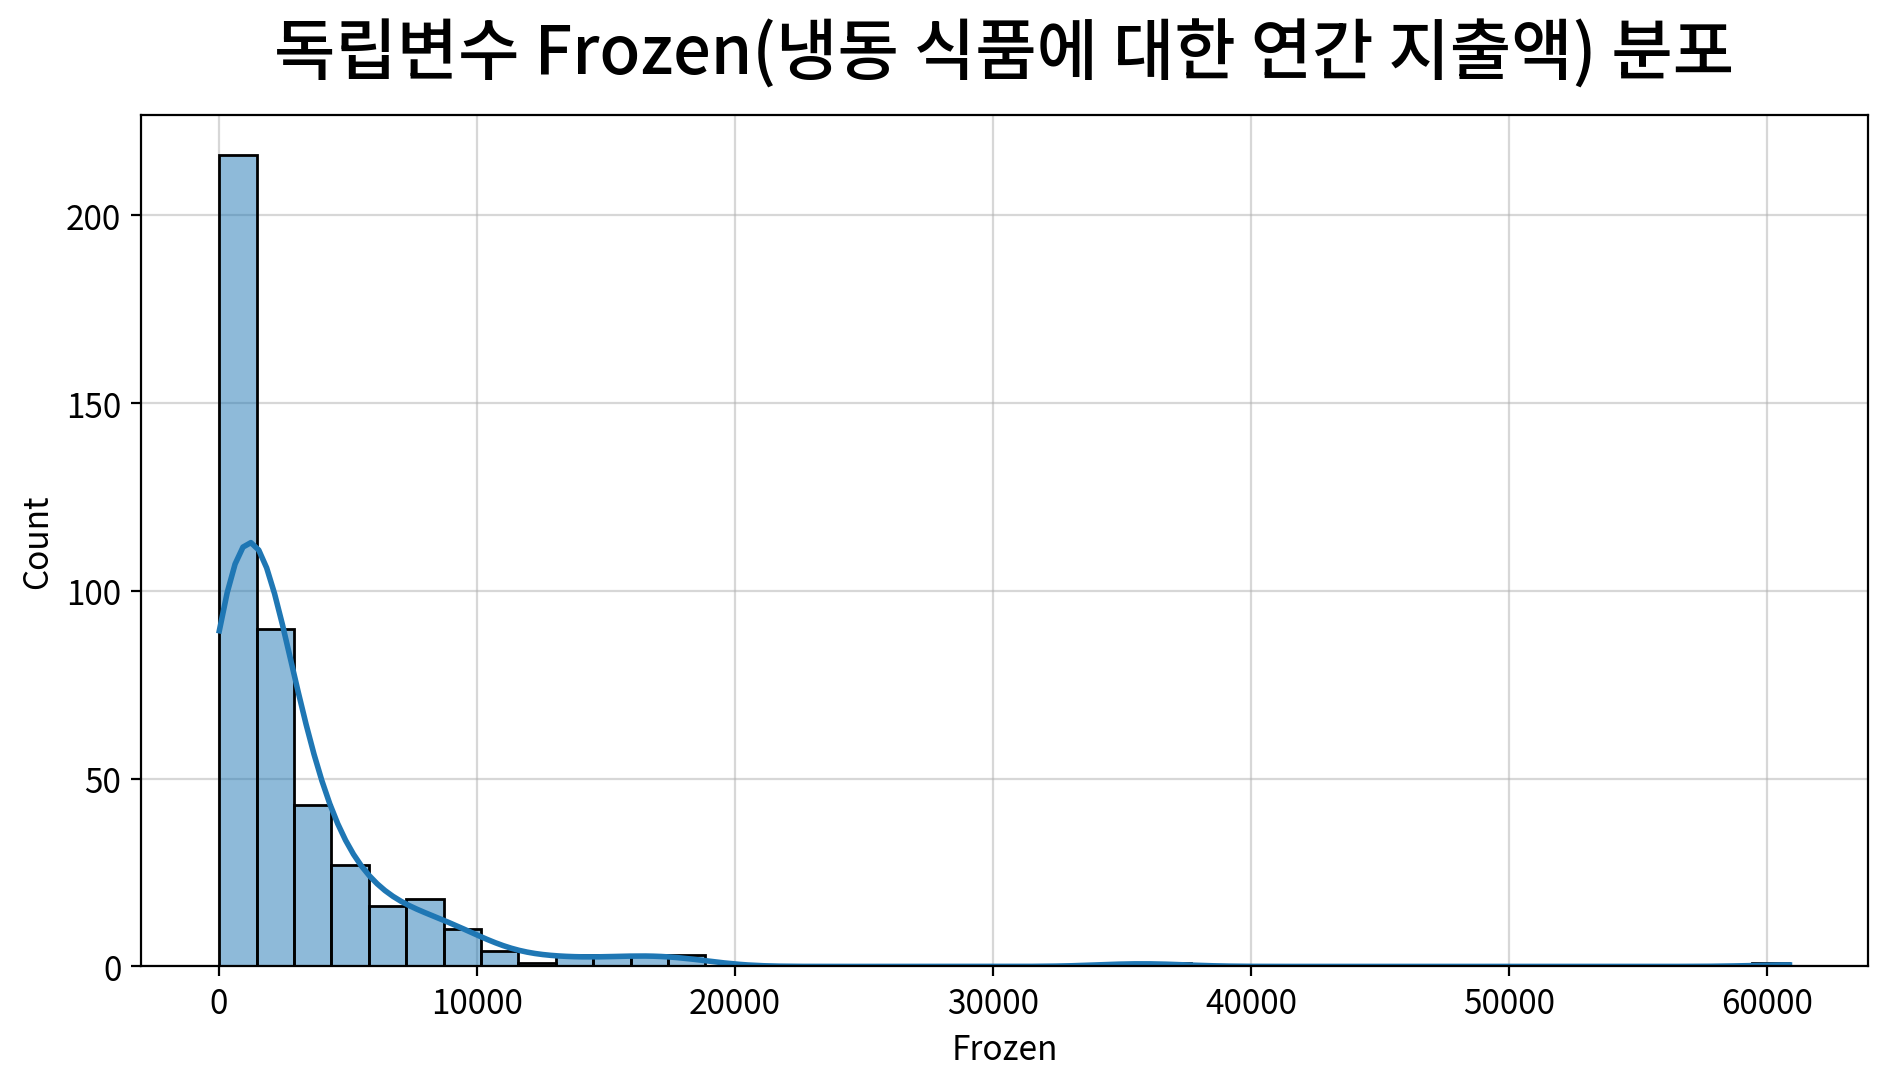

,Frozen
count,440.0
mean,3071.931818
std,4854.673333
min,25.0
25%,742.25
50%,1526.0
75%,3554.25
max,60869.0
rel_diff,1.013061
rdiff_flag,large_diff


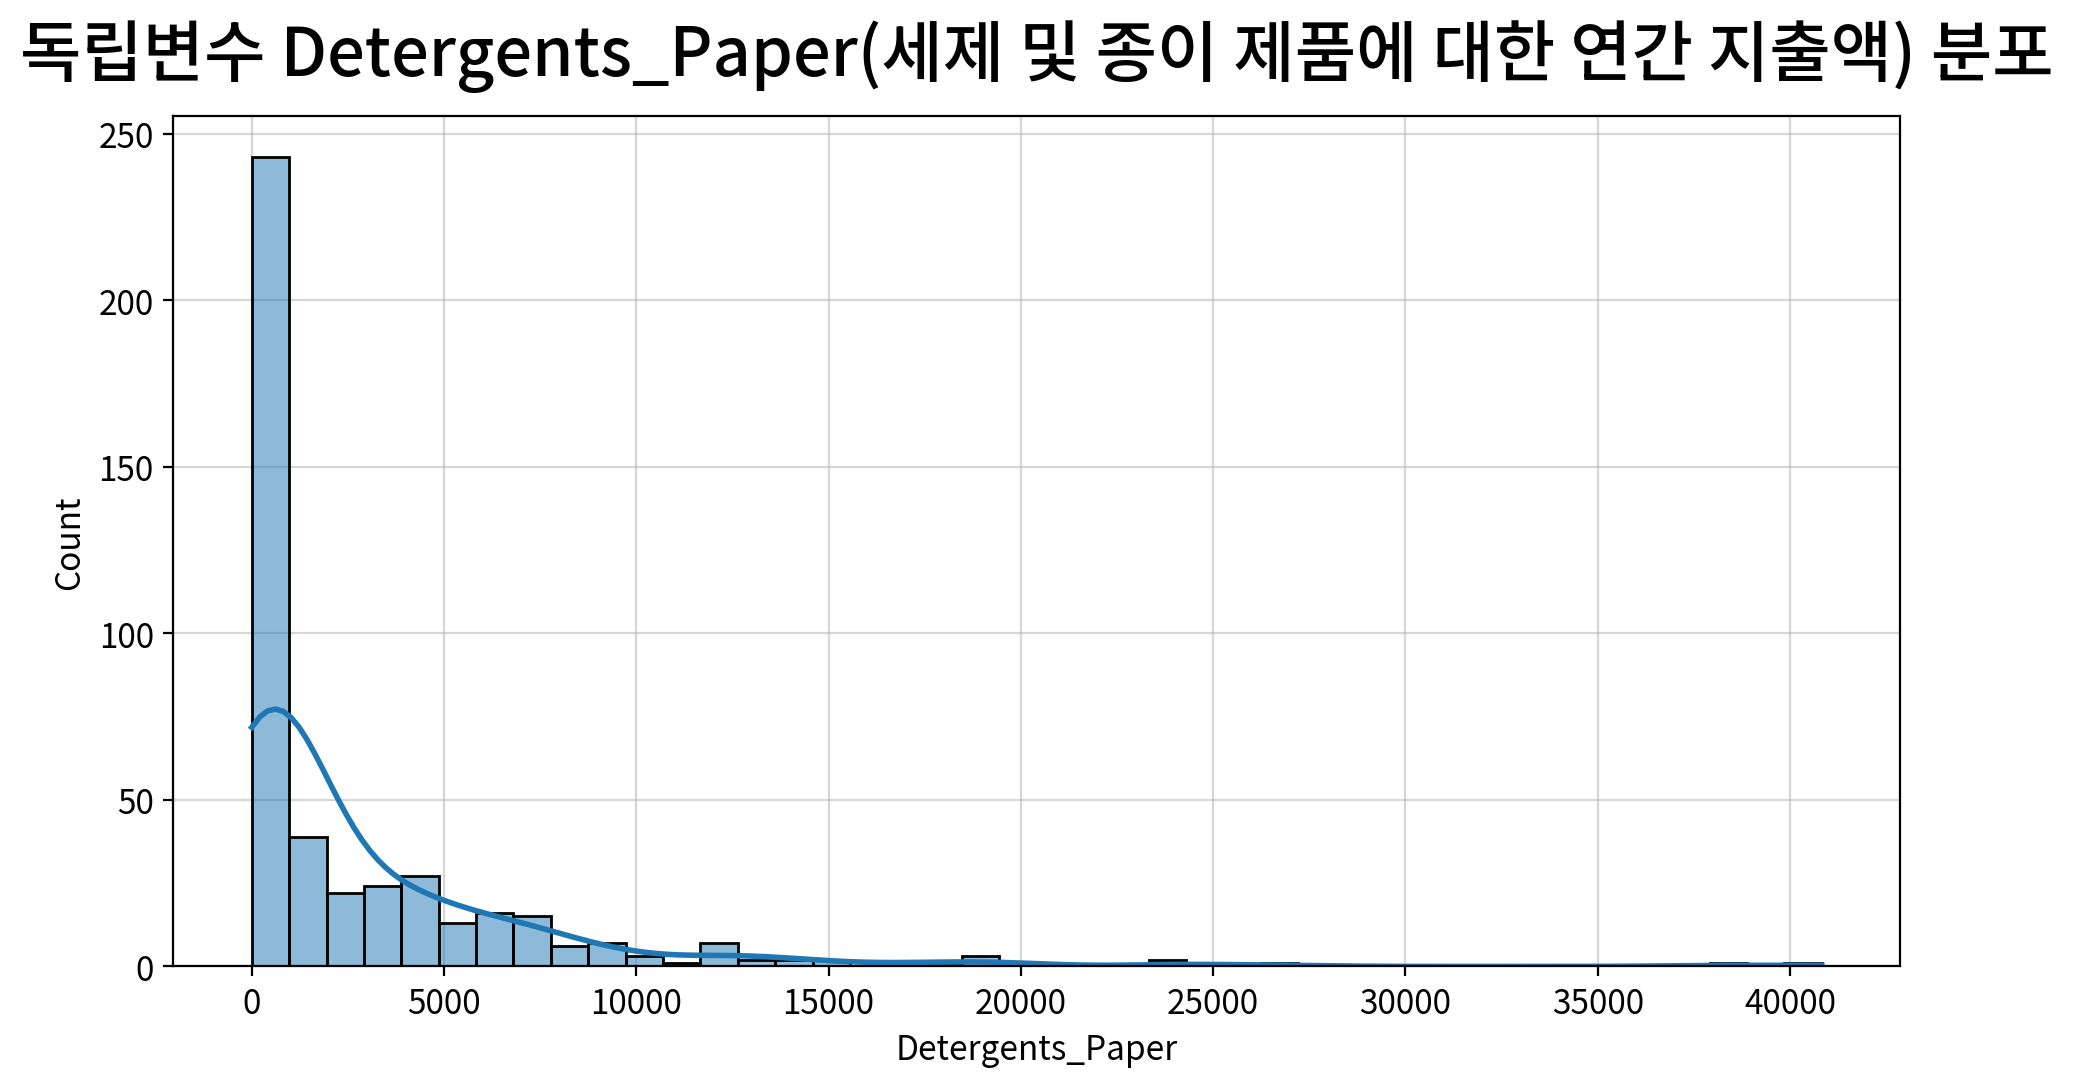

,Detergents_Paper
count,440.0
mean,2881.493182
std,4767.854448
min,3.0
25%,256.75
50%,816.5
75%,3922.0
max,40827.0
rel_diff,2.529079
rdiff_flag,large_diff


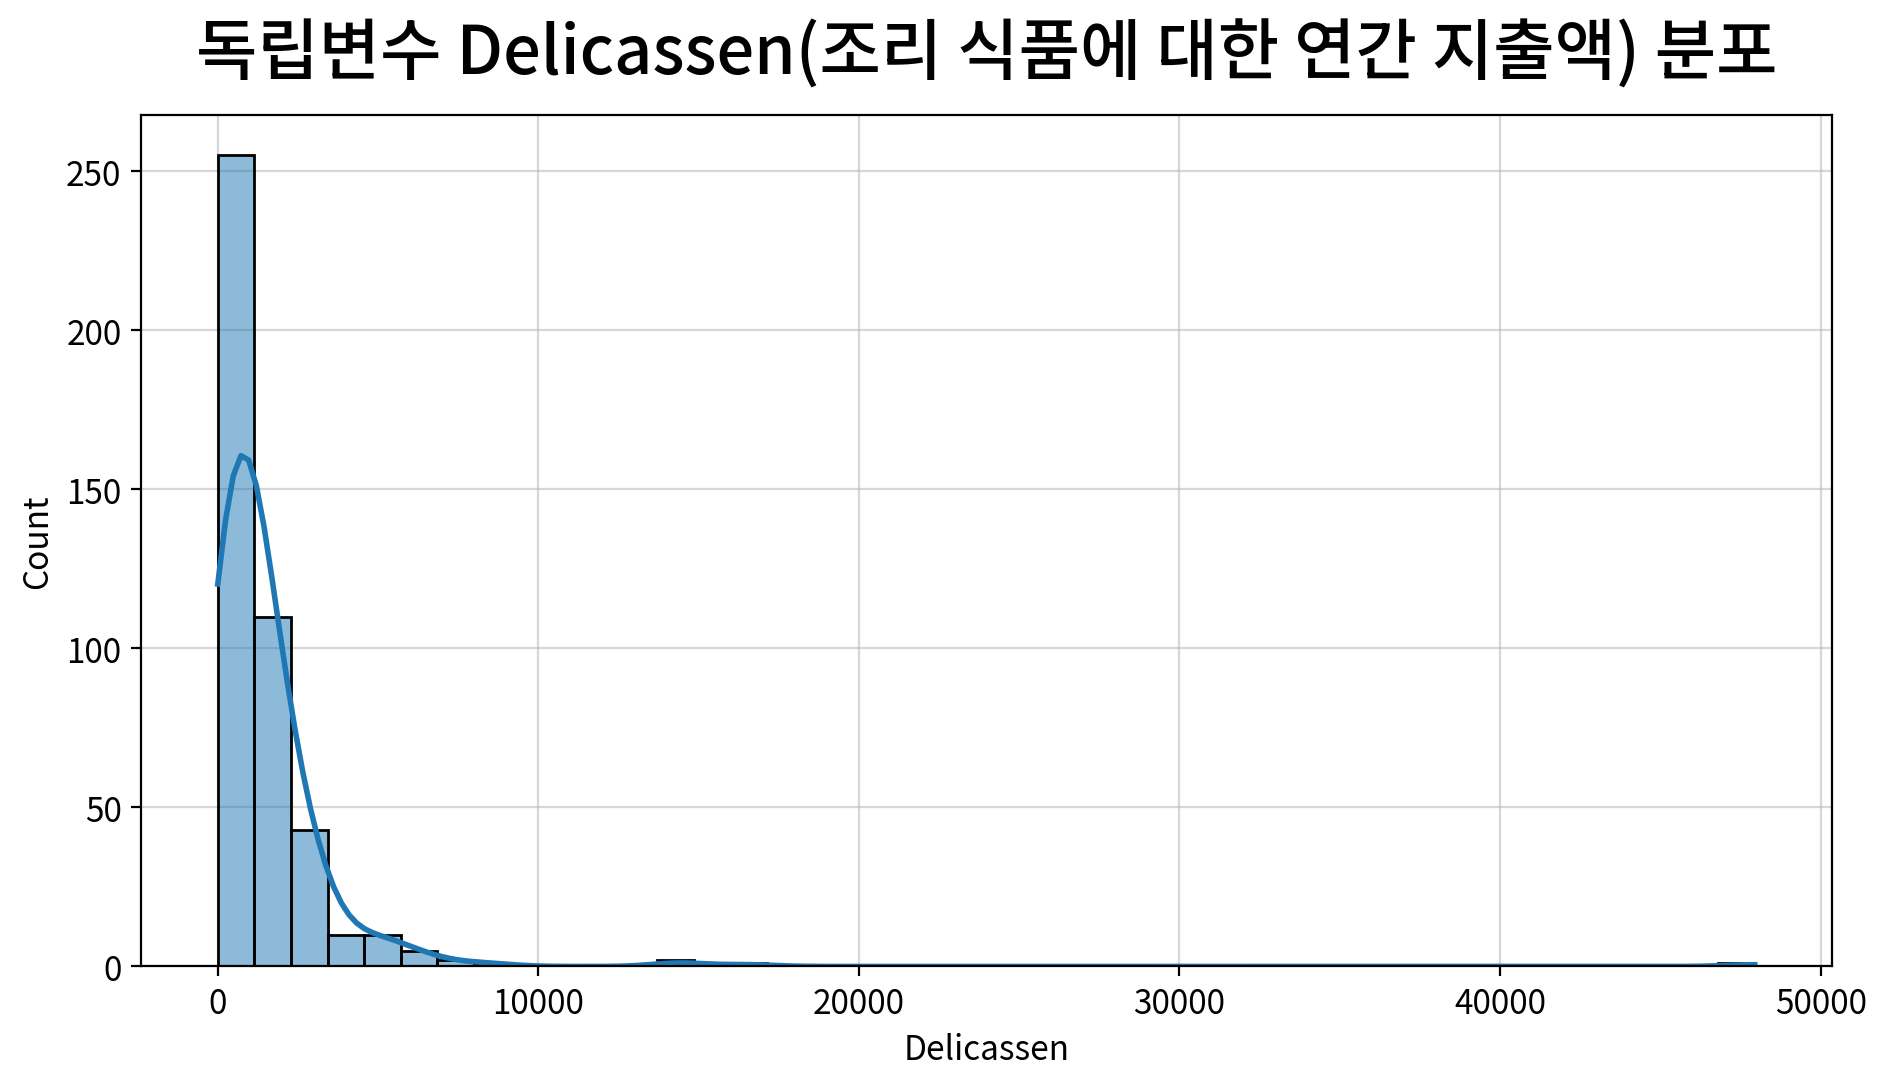

,Delicassen
count,440.0
mean,1524.870455
std,2820.105937
min,3.0
25%,408.25
50%,965.5
75%,1820.25
max,47943.0
rel_diff,0.579358
rdiff_flag,large_diff


In [17]:
for i in num_cols:
    my_plot.histplot(data=df, x=i, kde=True, width=960, height=560,
                     title = f'독립변수 {i}({column_means[i]}) 분포')
    display(num_desc[num_desc.index == i].T)

In [18]:
# 단변량 확인 후, 로그변환 여부 확정필요!
# - 다 로그 필요함! / 우측꼬리분포임! / 각 skew 값 확인하여 해석 필요

In [19]:
# 명목형 변수 2개 (채널 과 지역)
# 추후에 파이차트 그릴 예정으로, 비어놓음! 카운트 플롯 의미없음!
# 추가 필요 내용:
#- 프로젝트 개요 및 배경
#- 데이터셋 정리?? - 컬럼표
#- 가설 / 질문
#- 기본전처리 해석
#- 품질점검 해석


### 3) 이변량 분석

#### 3-1 독립표본 T-test (2집단 명목형 종속변수 - 연속형 독립변수)


#### > Channel(고객 채널) → Fresh

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

1 vs. 2: Mann-Whitney-Wilcoxon test two-sided, P_val:1.837e-04 U_stat=2.582e+04


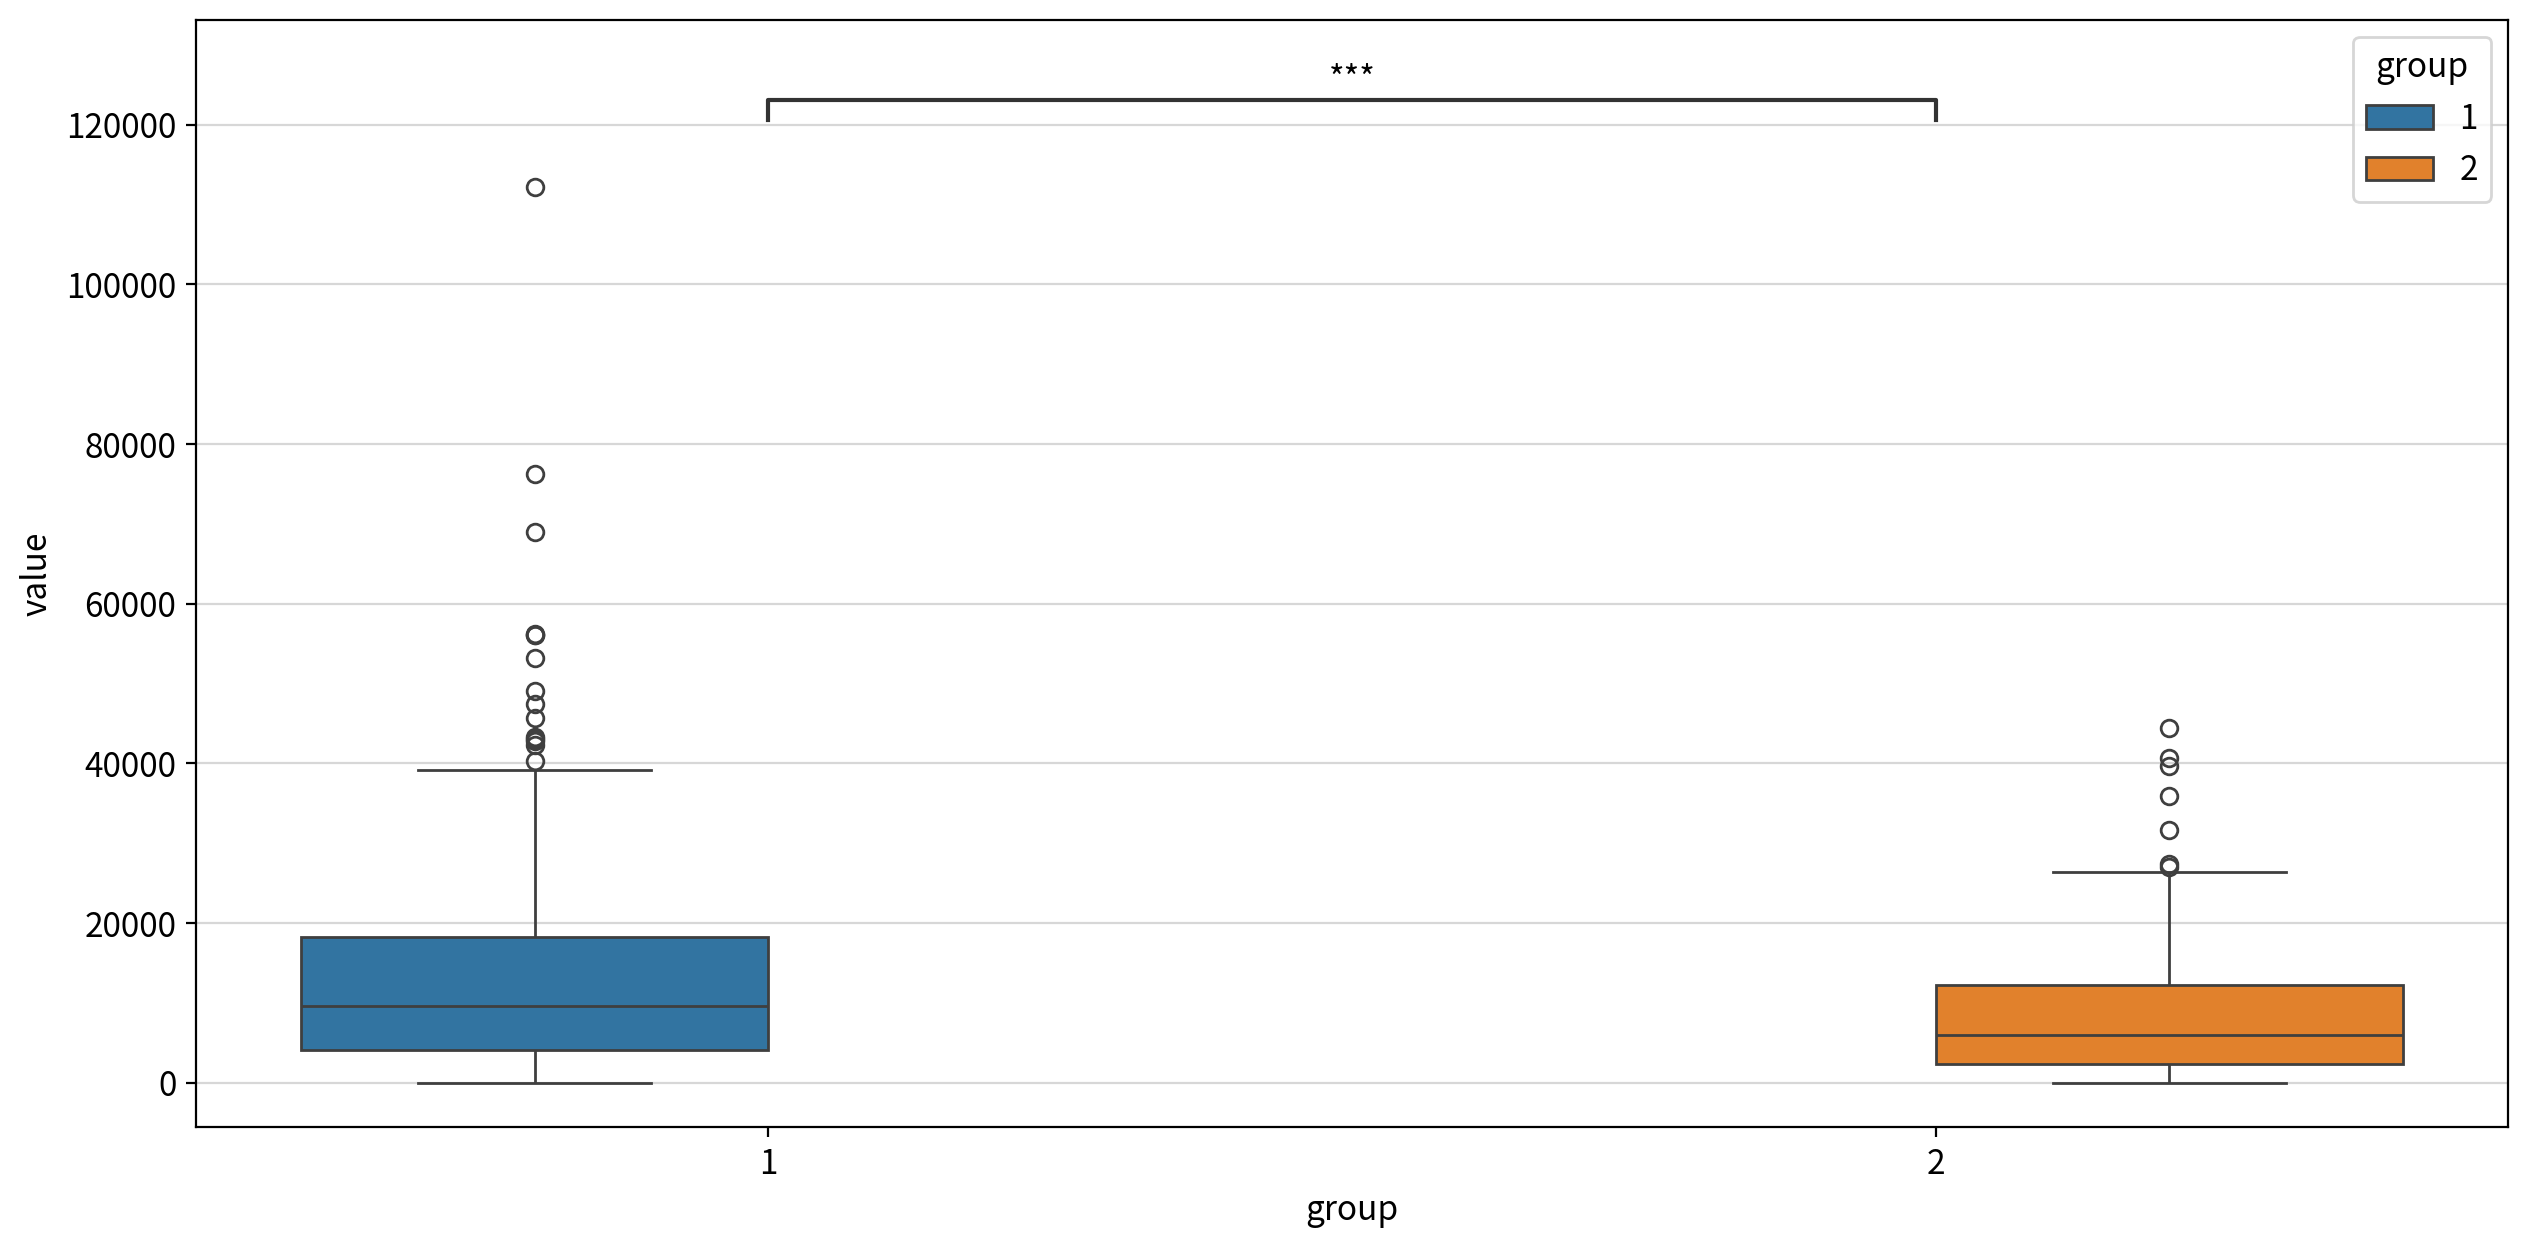

statistic  p-value  significant result
test                alternative                                        
Mann-Whitney U test two-sided      25823.0   0.0002         True  1 ≠ 2
                    less           25823.0   0.9999        False  1 ≥ 2
                    greater        25823.0   0.0001         True  1 > 2

#### > Channel(고객 채널) → Milk

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

1 vs. 2: Mann-Whitney-Wilcoxon test two-sided, P_val:7.712e-38 U_stat=5.122e+03


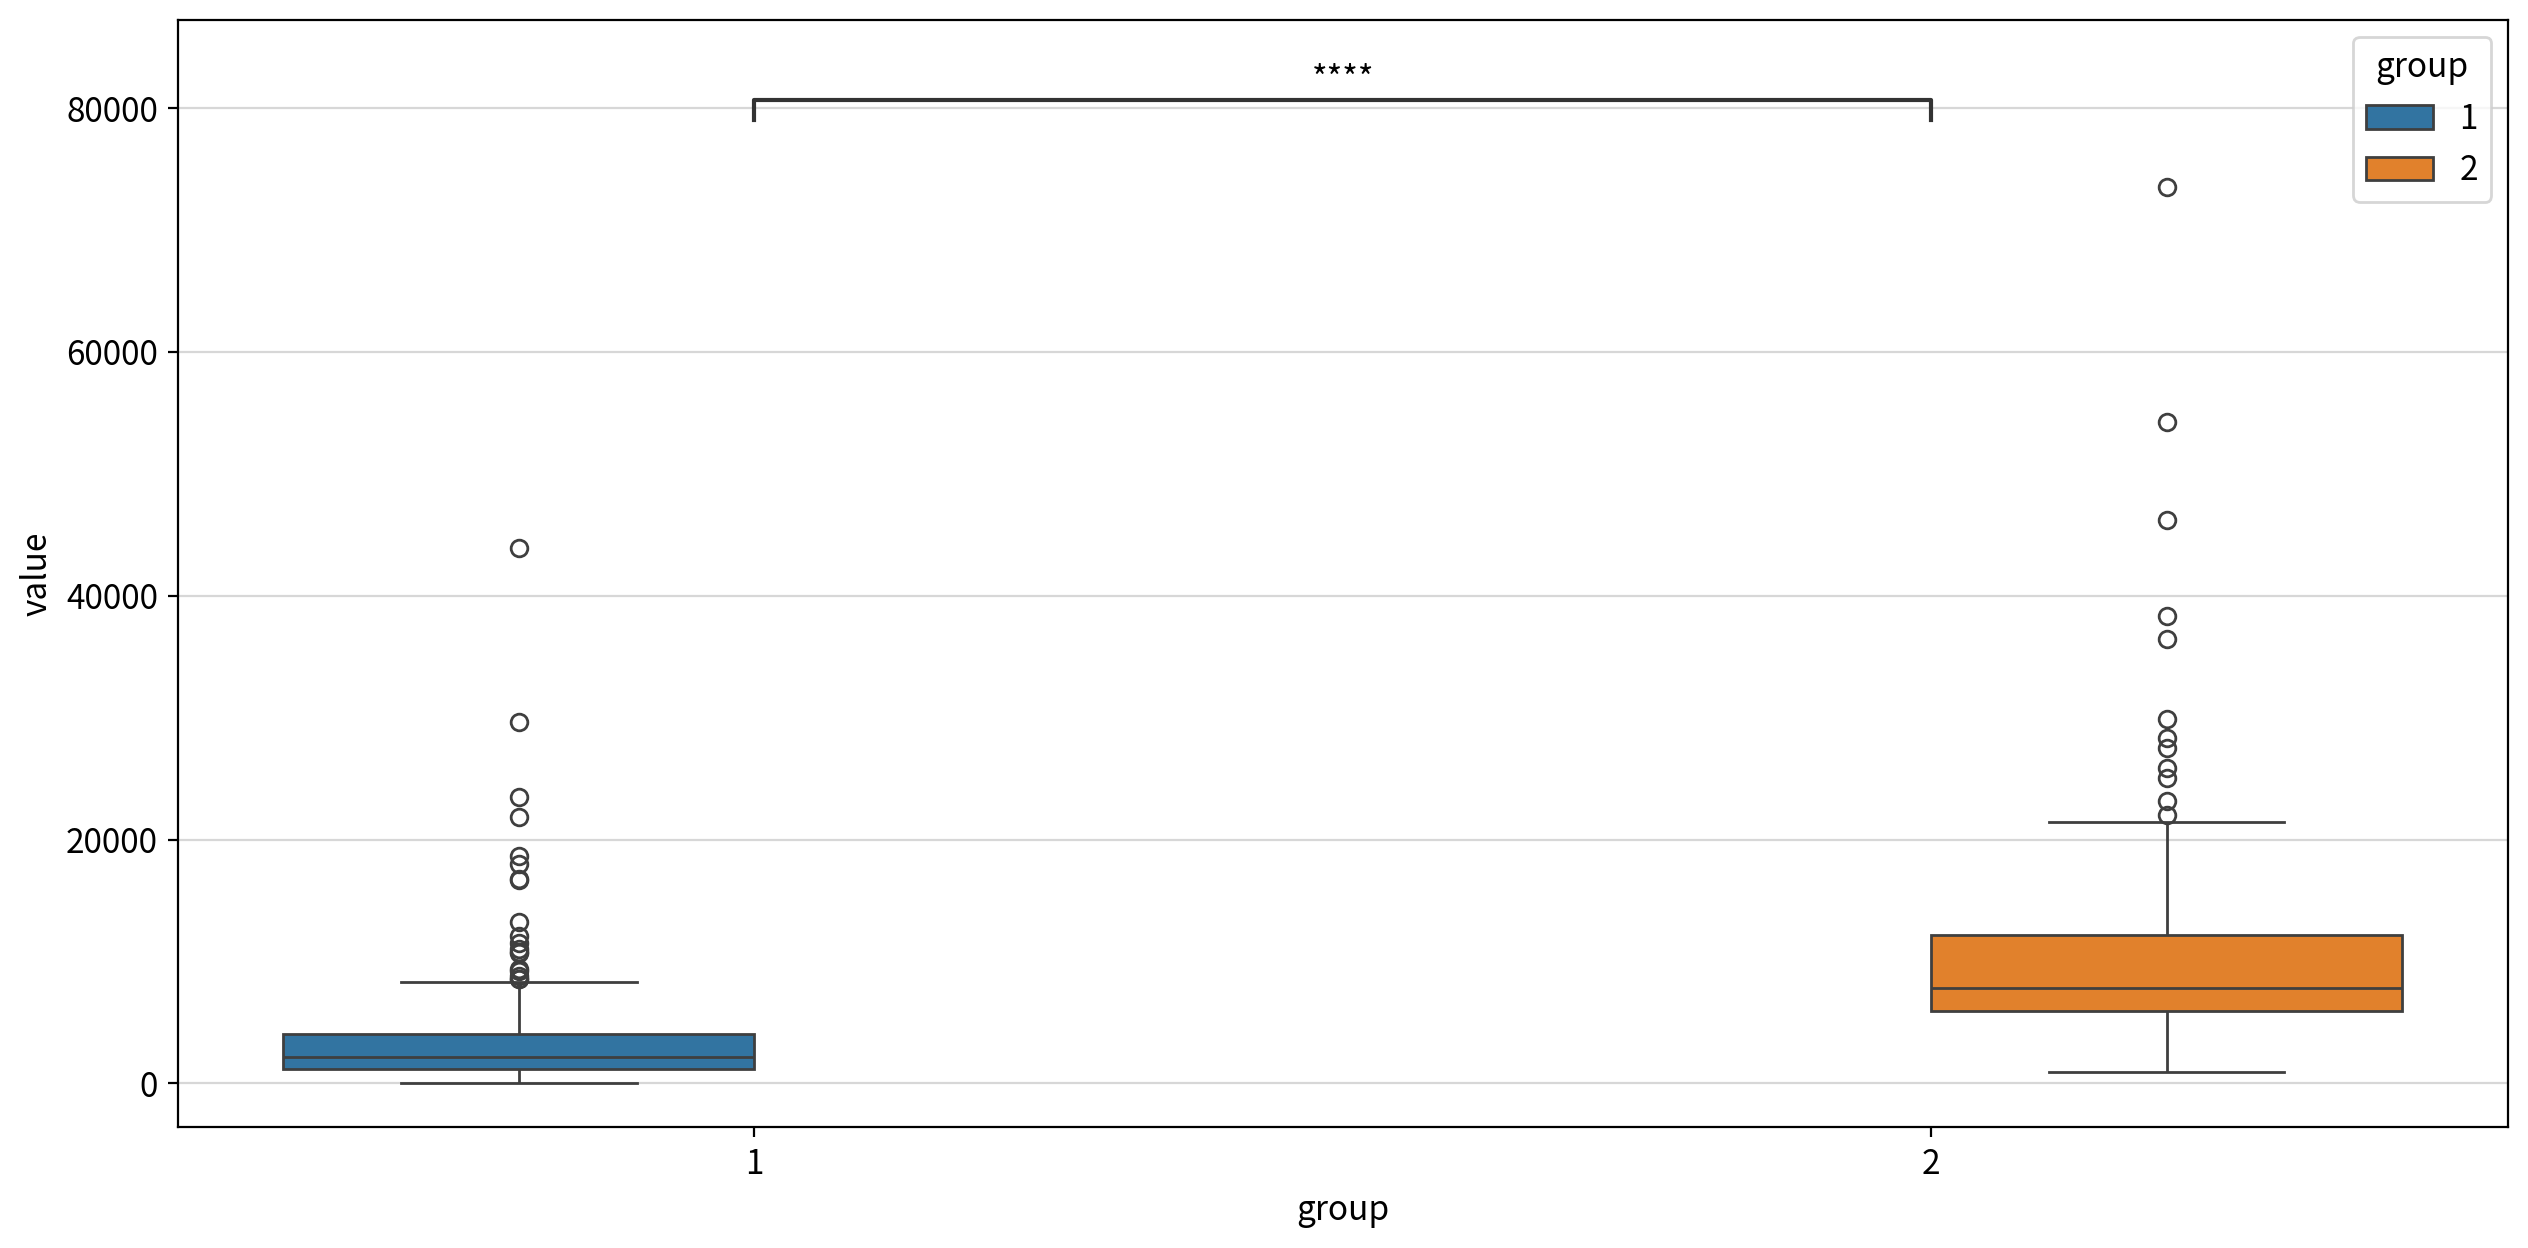

statistic  p-value  significant result
test                alternative                                        
Mann-Whitney U test two-sided       5122.5      0.0         True  1 ≠ 2
                    less            5122.5      0.0         True  1 < 2
                    greater         5122.5      1.0        False  1 ≤ 2

#### > Channel(고객 채널) → Grocery

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

1 vs. 2: Mann-Whitney-Wilcoxon test two-sided, P_val:6.637e-50 U_stat=2.635e+03


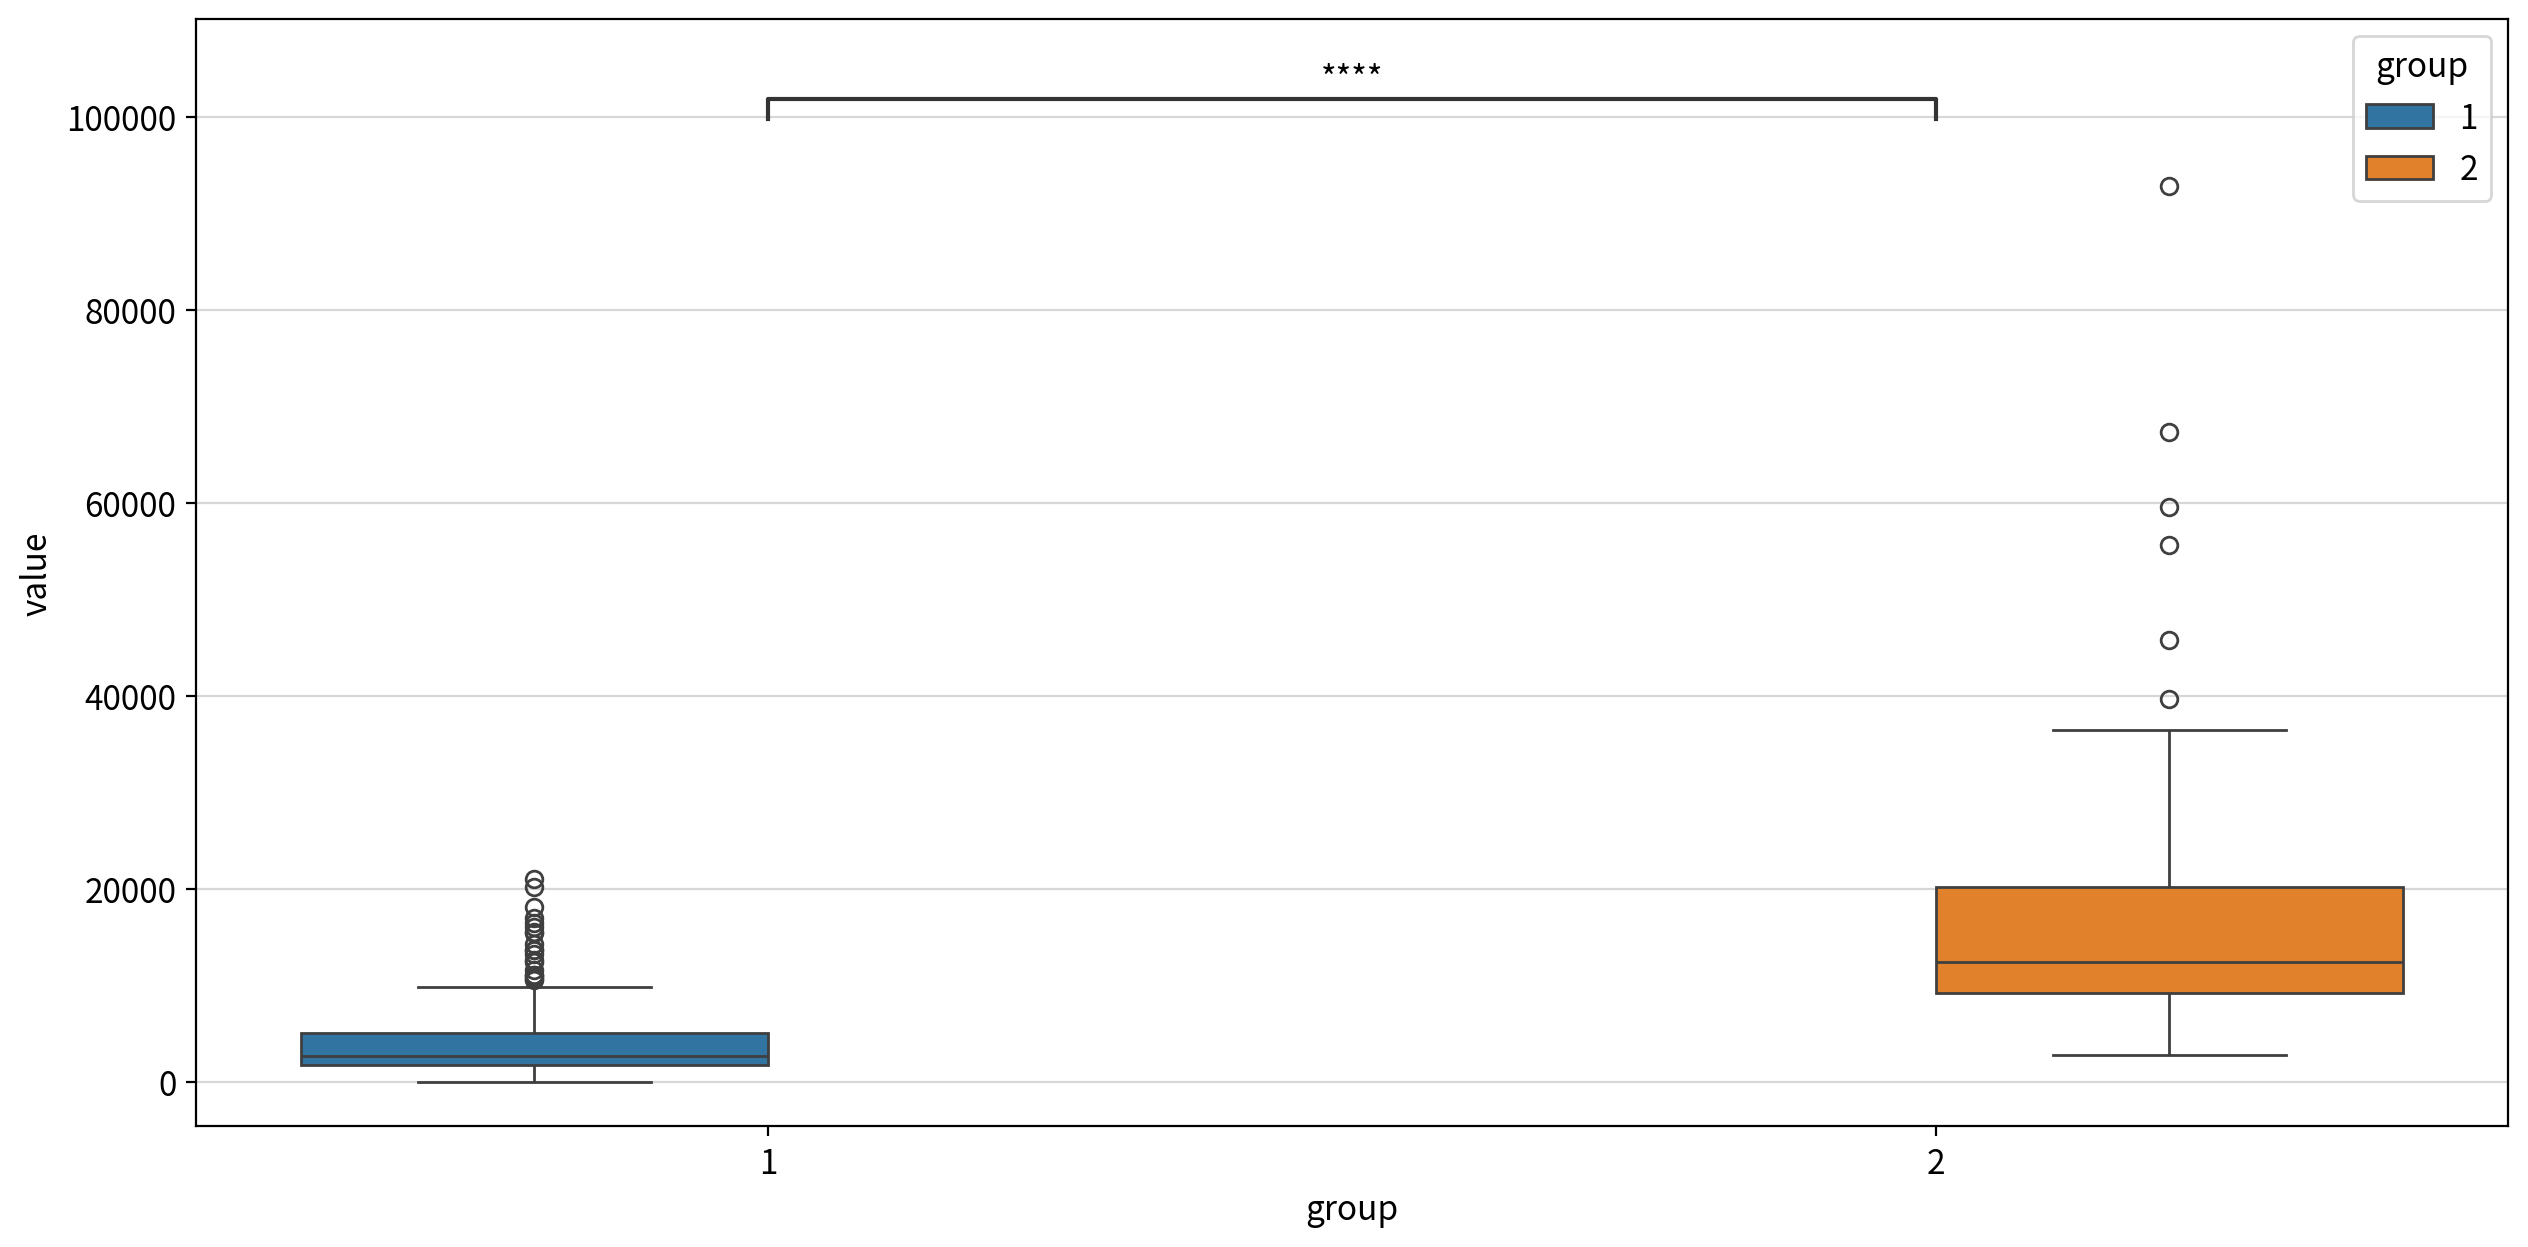

statistic  p-value  significant result
test                alternative                                        
Mann-Whitney U test two-sided       2635.0      0.0         True  1 ≠ 2
                    less            2635.0      0.0         True  1 < 2
                    greater         2635.0      1.0        False  1 ≤ 2

#### > Channel(고객 채널) → Frozen

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

1 vs. 2: Mann-Whitney-Wilcoxon test two-sided, P_val:7.402e-07 U_stat=2.733e+04


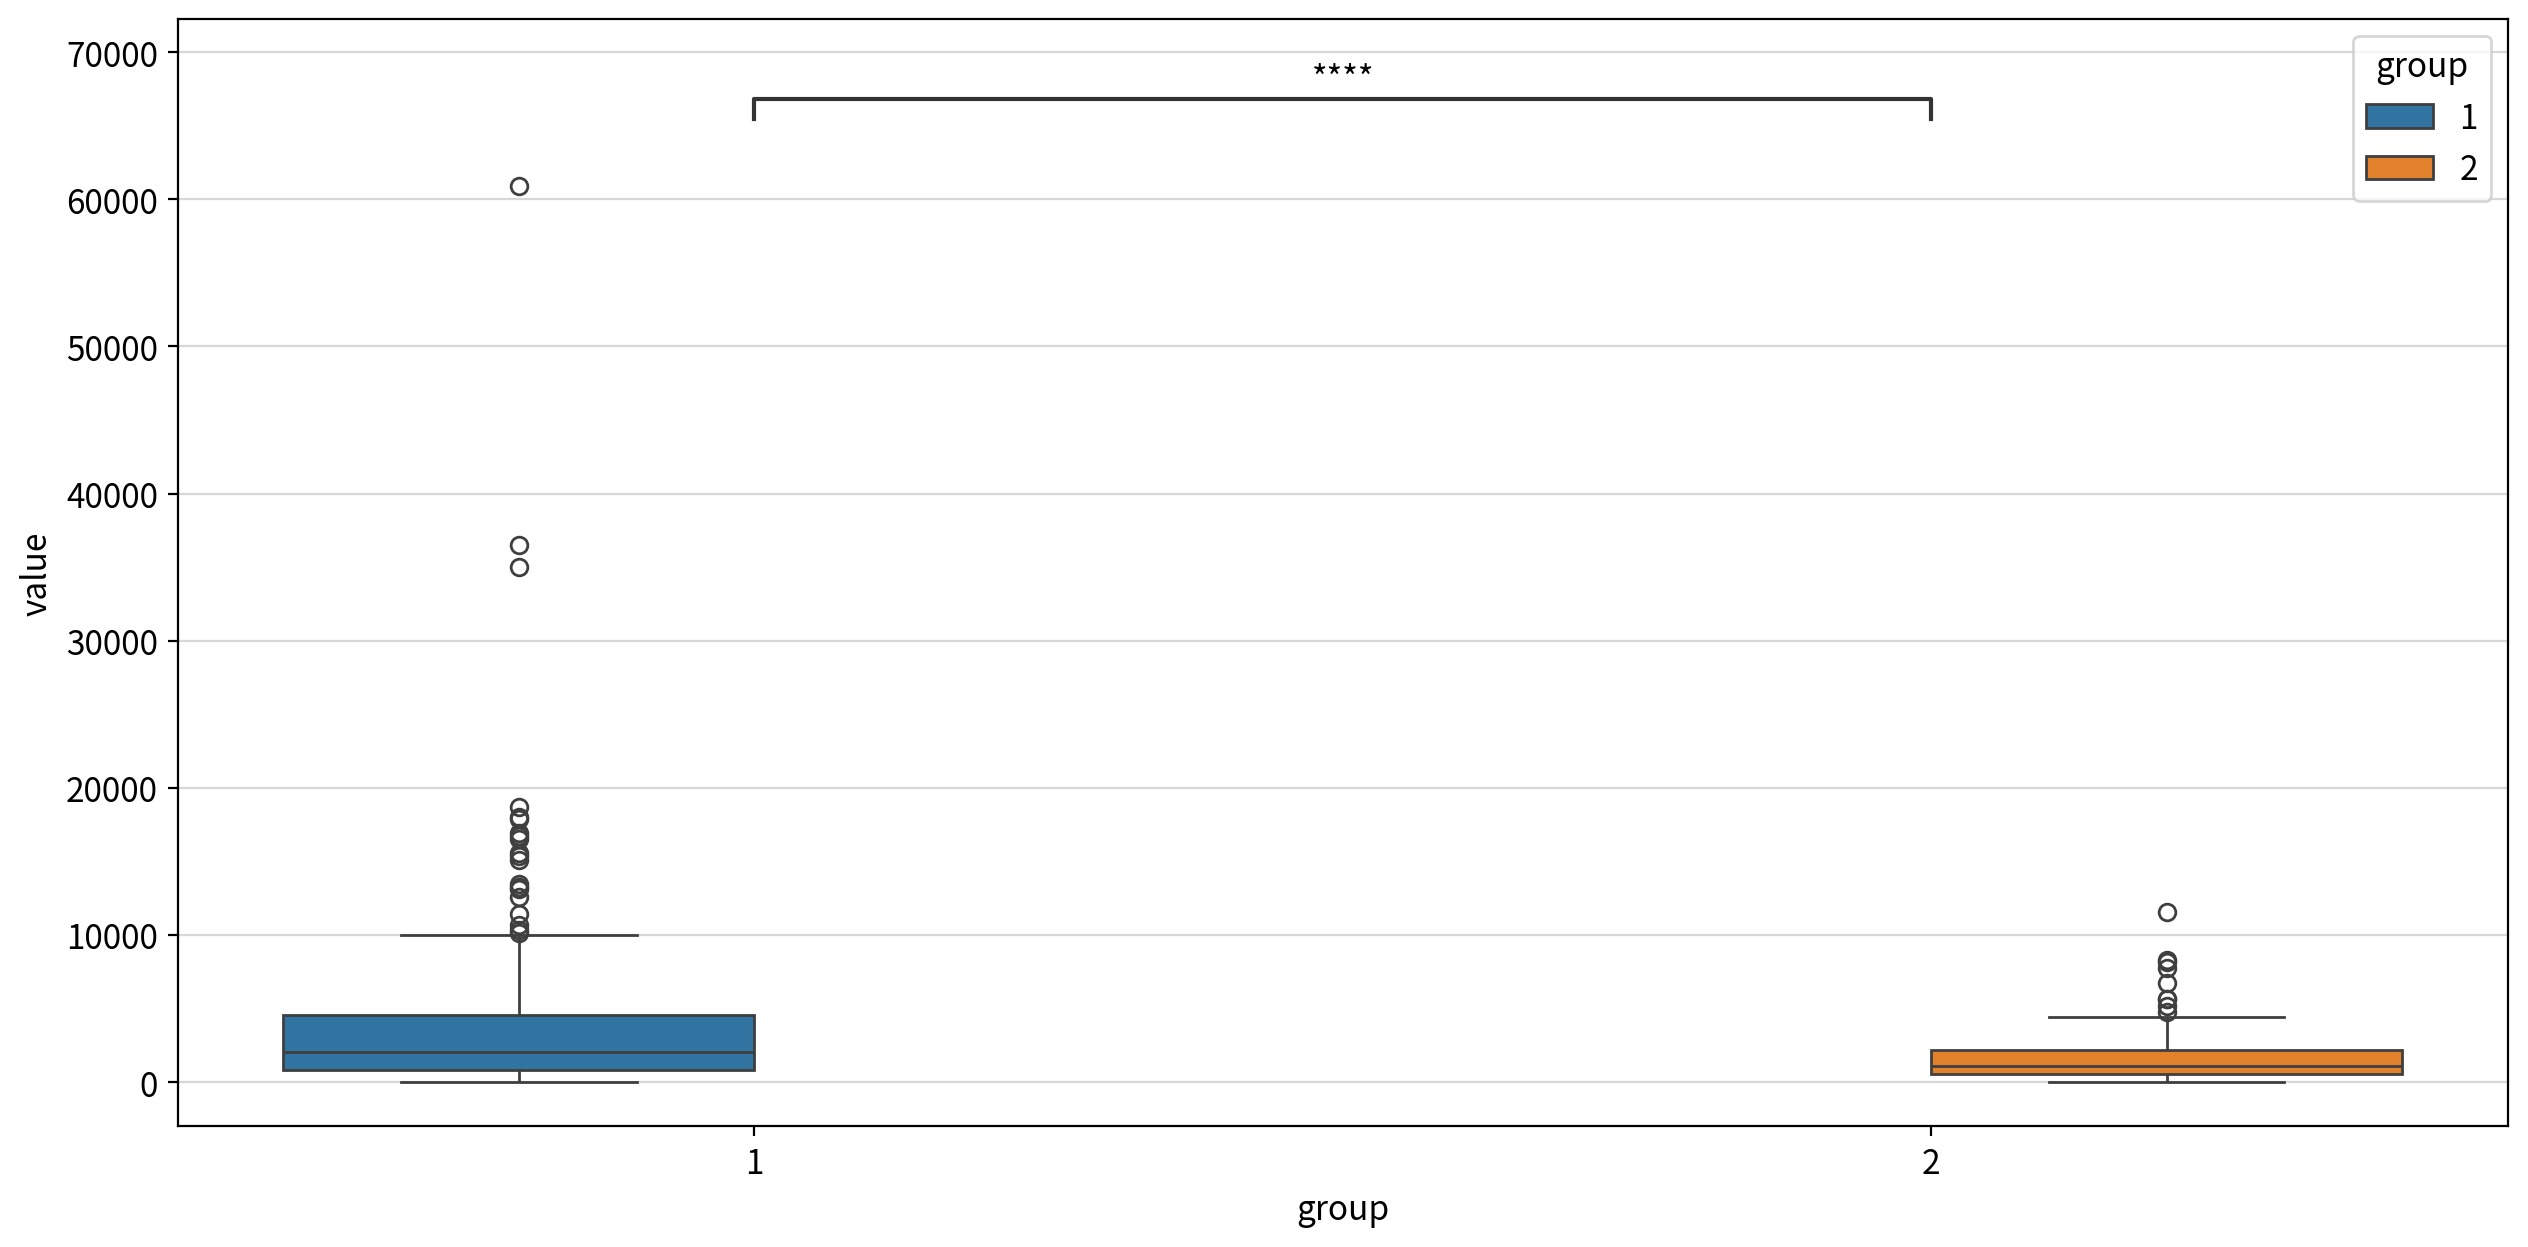

statistic  p-value  significant result
test                alternative                                        
Mann-Whitney U test two-sided      27332.0      0.0         True  1 ≠ 2
                    less           27332.0      1.0        False  1 ≥ 2
                    greater        27332.0      0.0         True  1 > 2

#### > Channel(고객 채널) → Detergents_Paper

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

1 vs. 2: Mann-Whitney-Wilcoxon test two-sided, P_val:4.591e-55 U_stat=1.667e+03


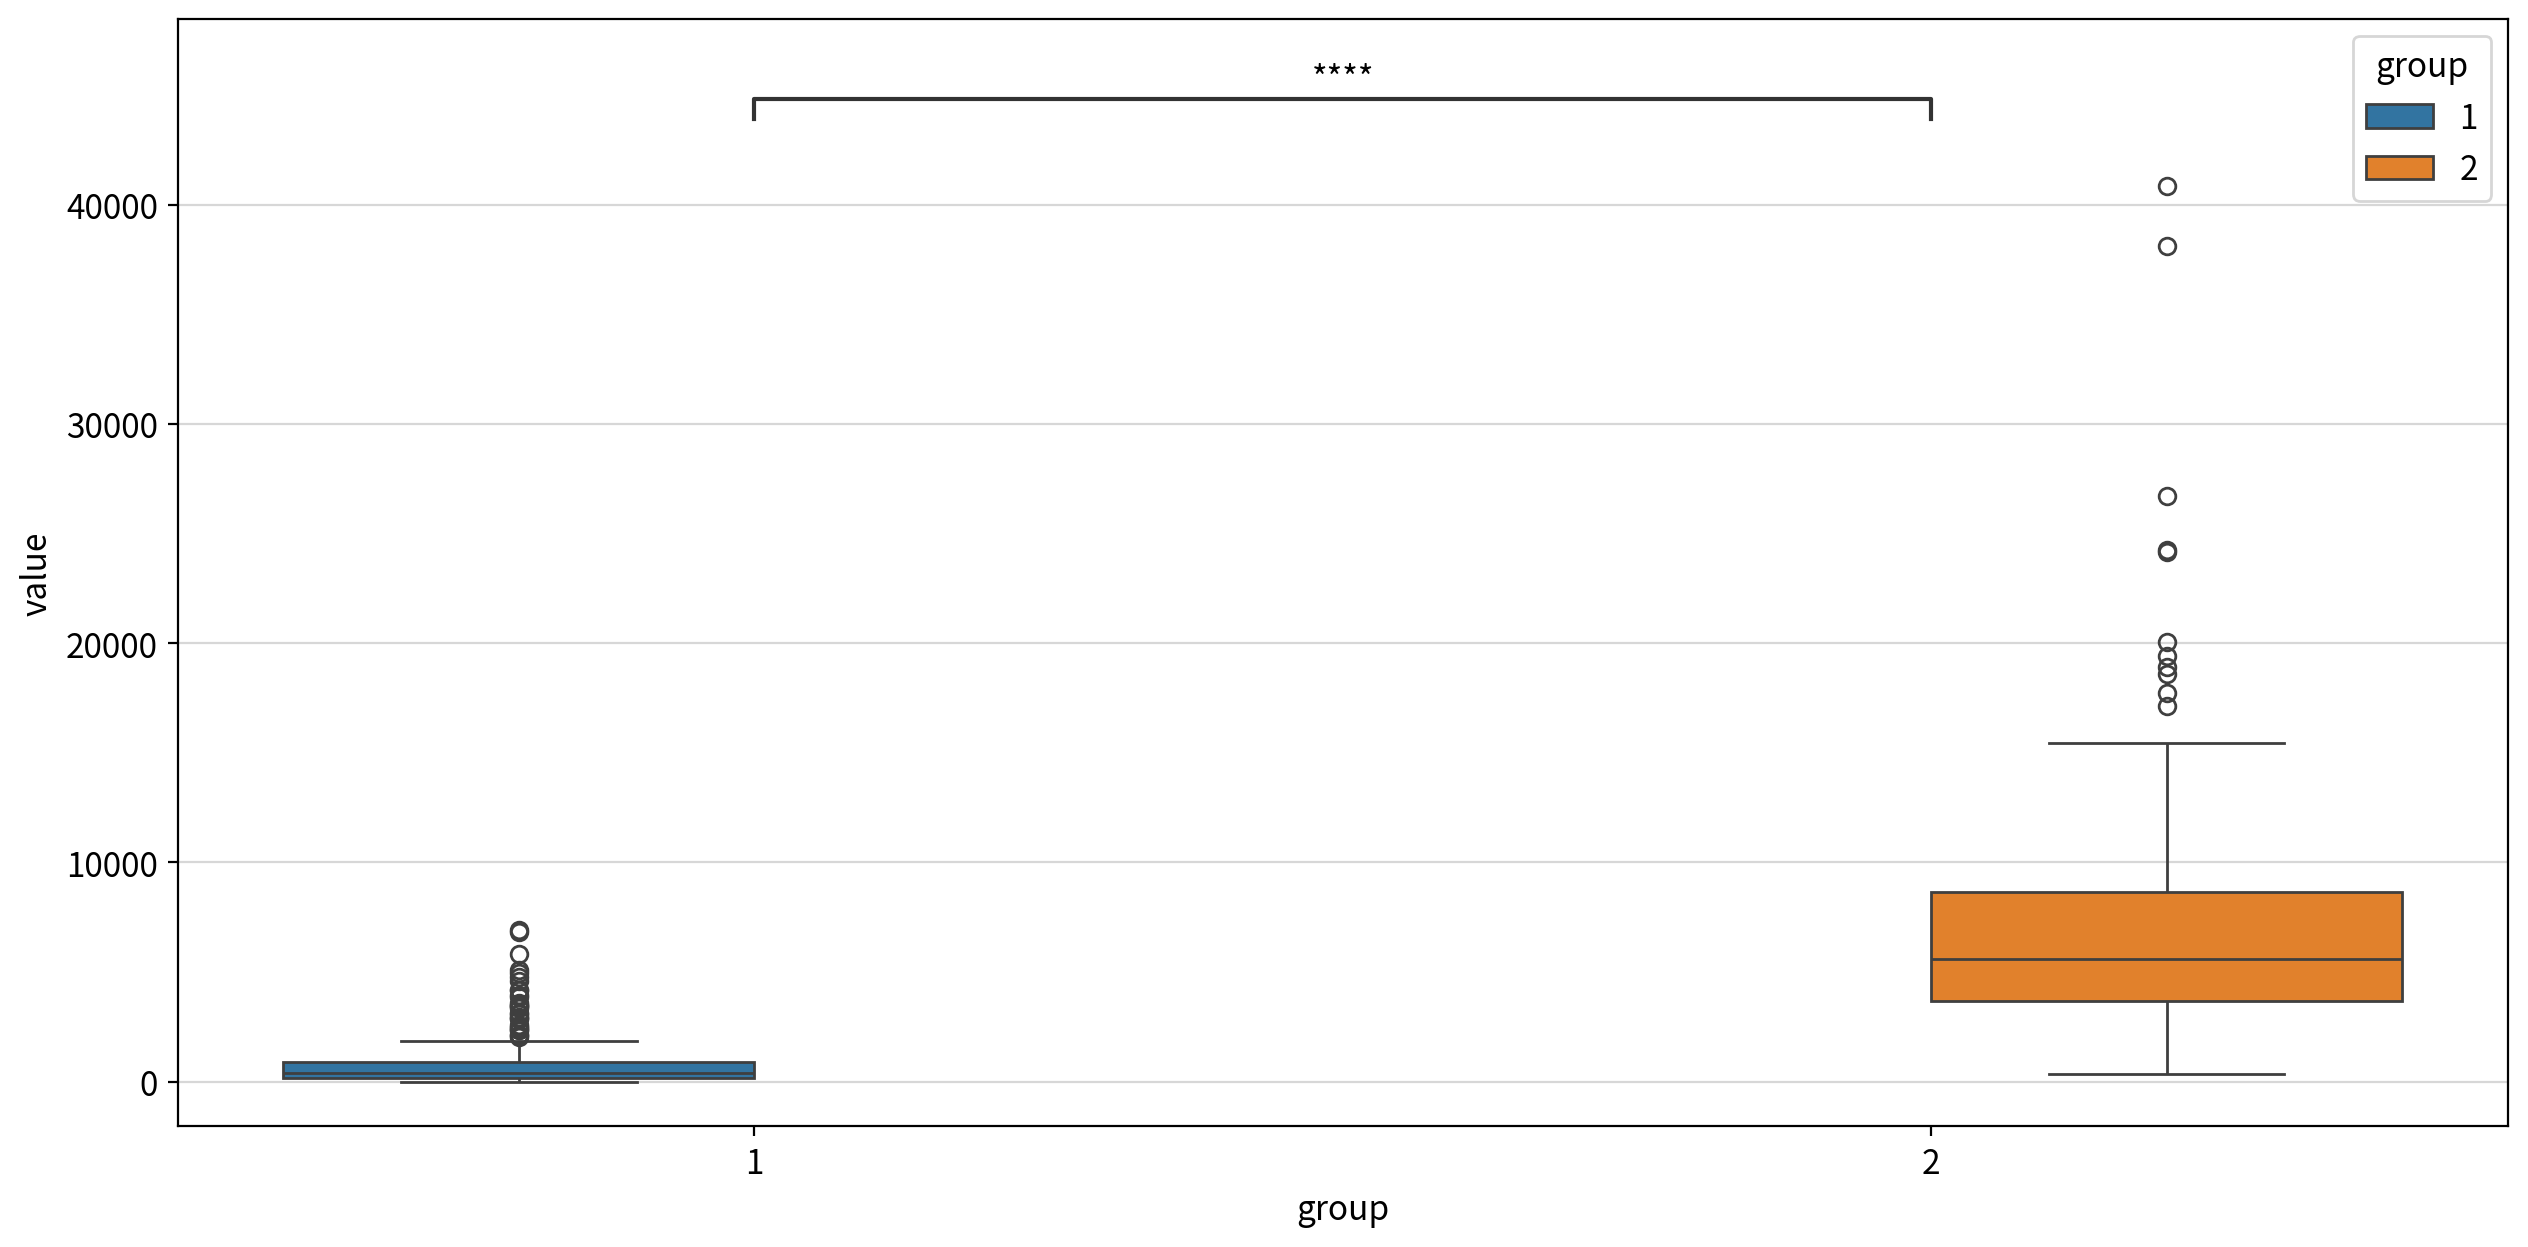

statistic  p-value  significant result
test                alternative                                        
Mann-Whitney U test two-sided       1667.0      0.0         True  1 ≠ 2
                    less            1667.0      0.0         True  1 < 2
                    greater         1667.0      1.0        False  1 ≤ 2

#### > Channel(고객 채널) → Delicassen

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

1 vs. 2: Mann-Whitney-Wilcoxon test two-sided, P_val:5.495e-04 U_stat=1.685e+04


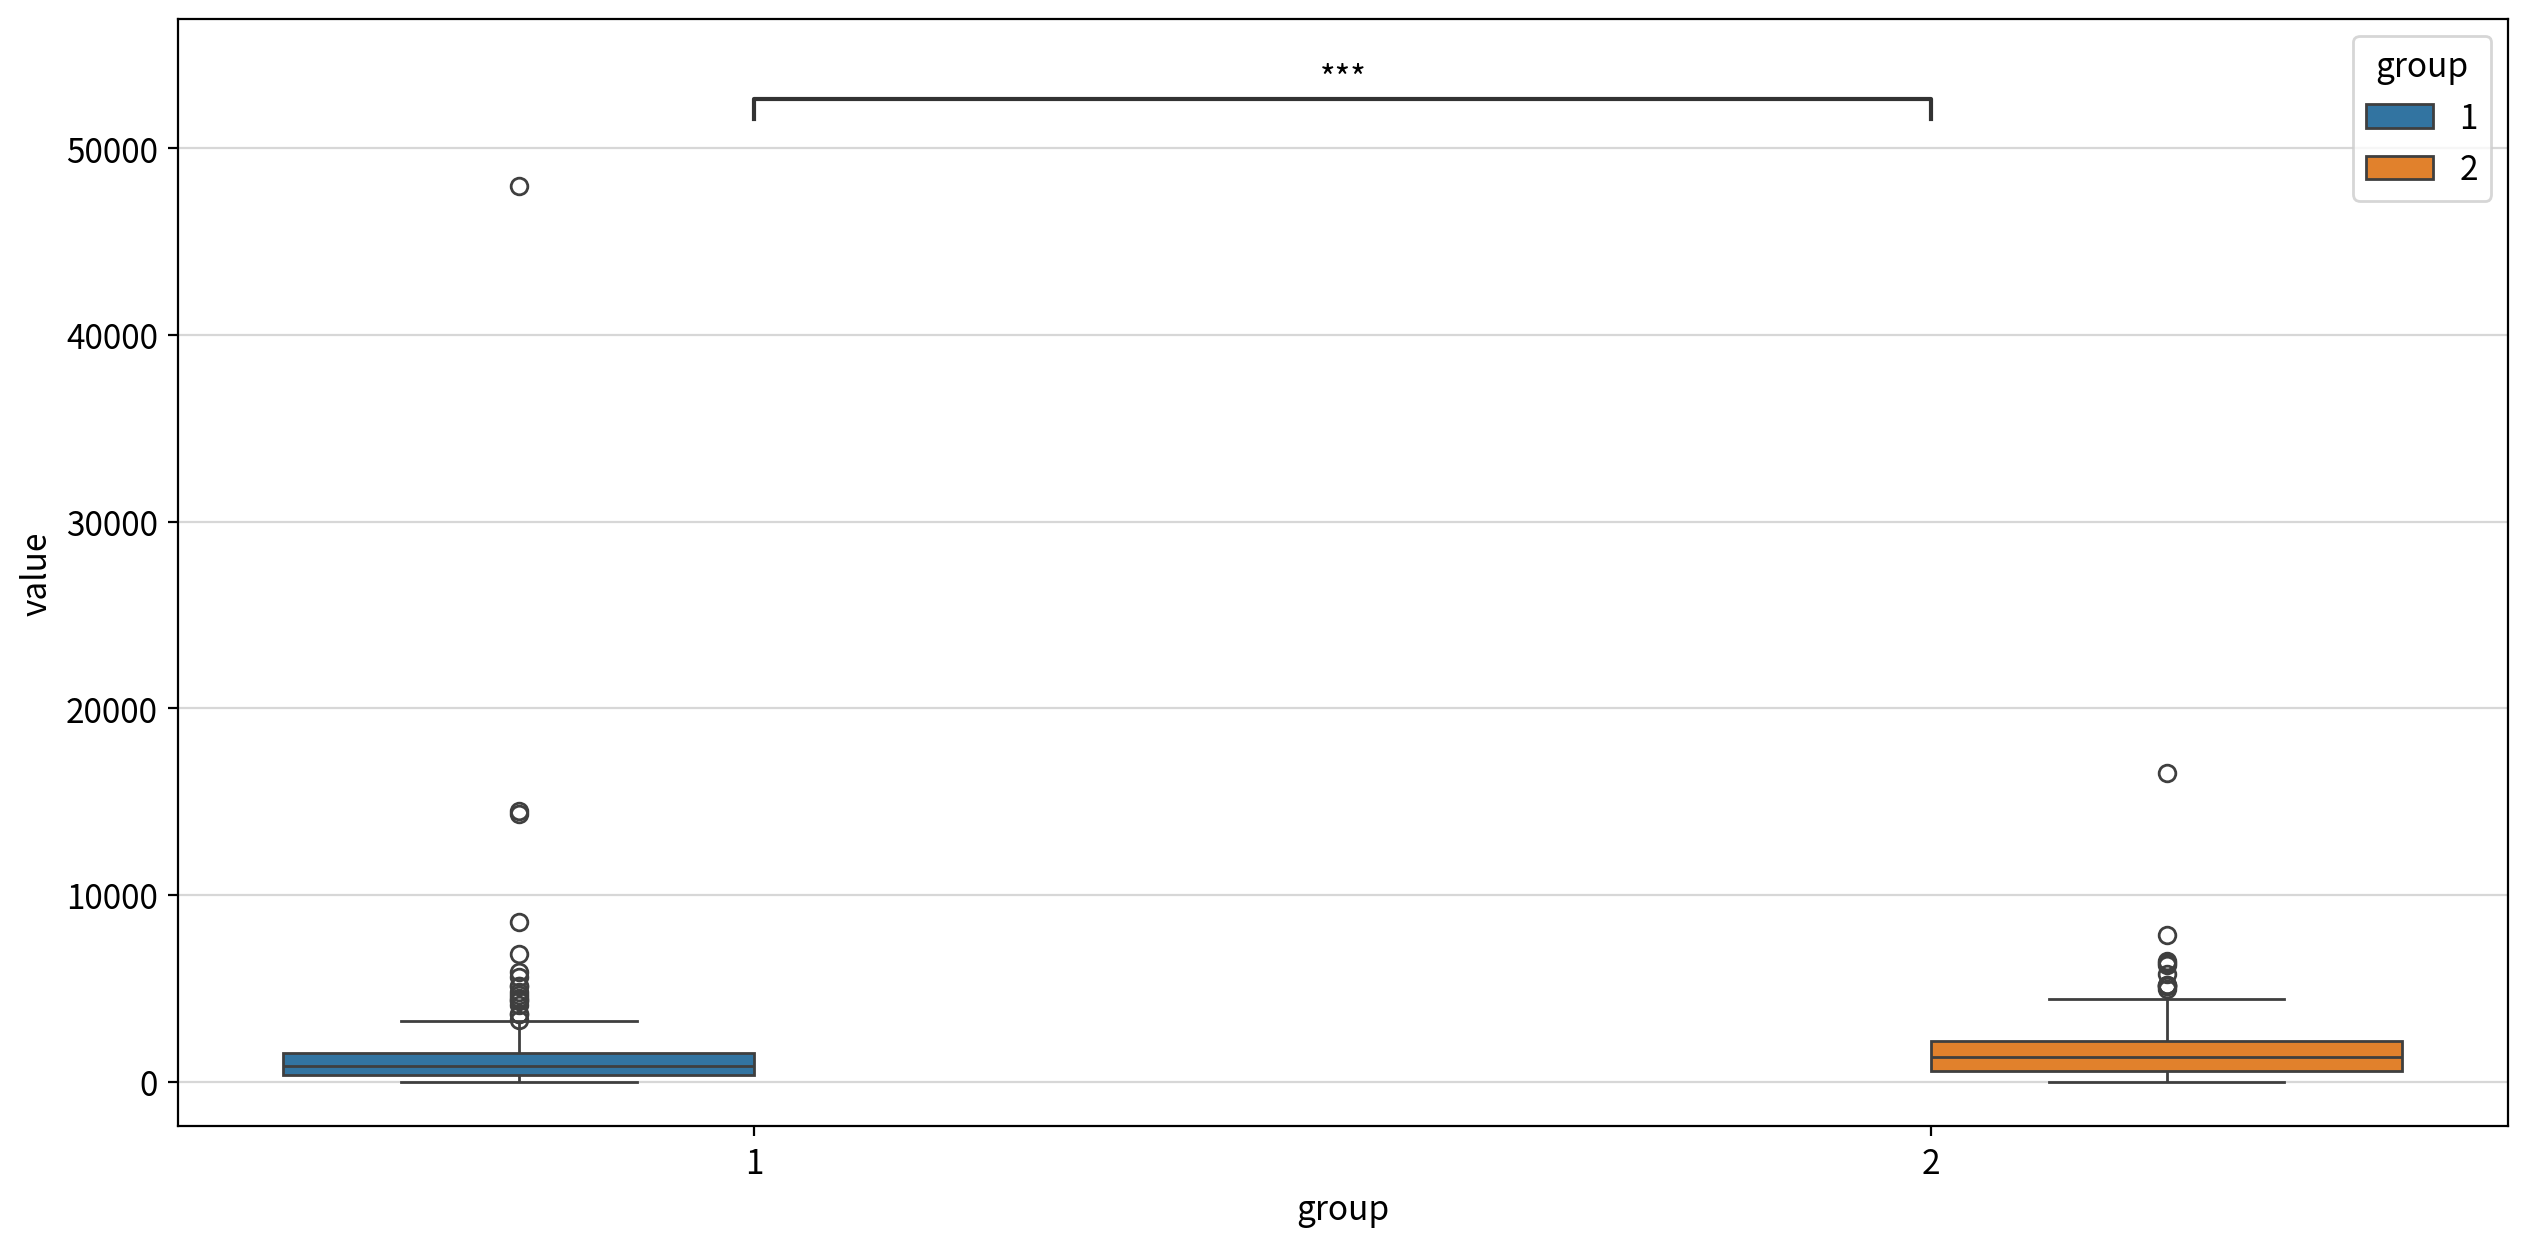

statistic  p-value  significant result
test                alternative                                        
Mann-Whitney U test two-sided      16848.5   0.0005         True  1 ≠ 2
                    less           16848.5   0.0003         True  1 < 2
                    greater        16848.5   0.9997        False  1 ≤ 2

In [20]:
for n in num_cols:
    display(Markdown(f'#### > {target}({column_means[target]}) → {n}'))

    wide_df = my_prep.long2wide(df, hue=target, values=n)
    display(my_stats.test_independent(wide_df, group1=wide_df.columns[0], 
                                      group2=wide_df.columns[1]))

### 4) 다변량 분석

In [21]:
corr = my_stats.multi_correlation(df, columns=num_cols, plot=False)
my_stats.correlation_summary(corr)

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Fresh,1.000,-0.084,-0.120,0.384,-0.198,0.238
Milk,-0.084,1.000,0.773,-0.093,0.680,0.373
Grocery,-0.120,0.773,1.000,-0.169,0.801,0.304
Frozen,0.384,-0.093,-0.169,1.000,-0.207,0.233
Detergents_Paper,-0.198,0.680,0.801,-0.207,1.000,0.183
Delicassen,0.238,0.373,0.304,0.233,0.183,1.000


,max-y,max-coef,count,columns
x,,,,
Grocery,Detergents_Paper,0.8013,2,"Detergents_Paper, Milk"
Detergents_Paper,Grocery,0.8013,1,Grocery
Milk,Grocery,0.7730,1,Grocery
Fresh,Frozen,0.3844,0,-
Frozen,Fresh,0.3844,0,-
Delicassen,Milk,0.3728,0,-


**4)** 로그변환 및 표준화(스케일링)

In [31]:
# log 변환 (연속형 컬럼)
log_df = my_prep.log_transform(df, log_columns=num_cols)
log_df.head()

컬럼        꼬리방향      변환식                   역변환식                                  왜도
----------------------------------------------------------------------------------------
Fresh     우측 꼬리     log(x)                exp(y)                   2.55 -> -1.62
Milk      우측 꼬리     log(x)                exp(y)                   4.04 -> -0.23
Grocery   우측 꼬리     log(x)                exp(y)                   3.58 -> -0.74
Frozen    우측 꼬리     log(x)                exp(y)                   5.89 -> -0.36
Detergents_Paper우측 꼬리     log(x)                exp(y)                   3.62 -> -0.27
Delicassen우측 꼬리     log(x)                exp(y)                  11.11 -> -1.17


,Channel,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,9.446913,9.175335,8.930759,5.365976,7.891331,7.198931
1,2,8.861775,9.191158,9.166179,7.474205,8.099554,7.482119
2,2,8.756682,9.083416,8.946896,7.785305,8.165079,8.967504
3,1,9.492884,7.086738,8.347827,8.764678,6.228511,7.488853
4,2,10.026369,8.596004,8.881558,8.272571,7.482682,8.553525


In [30]:
# 스케일링 (연속형 컬럼)
scaling_df = my_prep.scaling(log_df, columns=num_cols)
scaling_df.head()

StandardScaler 적용 (6개 컬럼)
컬럼                            변환 전                  변환 후
--------------------------------------------------------
Fresh               1.10 ~ 11.63          -5.16 ~ 1.96
Milk                4.01 ~ 11.21          -3.81 ~ 2.86
Grocery             1.10 ~ 11.44          -6.59 ~ 2.69
Frozen              3.22 ~ 11.02          -3.18 ~ 2.90
Detergents_Paper        1.10 ~ 10.62          -3.31 ~ 2.23
Delicassen          1.10 ~ 10.78          -4.25 ~ 3.14


,Channel,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,0.484561,0.976070,0.439132,-1.508418,0.643001,0.407685
1,2,0.088766,0.990718,0.650291,0.134683,0.764127,0.623967
2,2,0.017680,0.890970,0.453606,0.377147,0.802243,1.758420
3,1,0.515656,-0.957573,-0.083722,1.140446,-0.324282,0.629110
4,2,0.876512,0.439720,0.395003,0.756909,0.405285,1.442246


**5)** 로그변환 및 표준화 통계점검

In [33]:
sc_desc = my_qtcheck.numerical_summary(scaling_df)
sc_desc.T

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.0,440.0,440.0,440.0,440.0,440.0
mean,-0.0,-0.0,-0.0,0.0,0.0,0.0
std,1.001138,1.001138,1.001138,1.001138,1.001138,1.001138
min,-5.162332,-3.808515,-6.585828,-3.181814,-3.308406,-4.251391
25%,-0.461641,-0.727747,-0.687551,-0.539108,-0.720084,-0.498921
50%,0.214925,0.06954,0.02322,0.022596,-0.047092,0.158486
75%,0.680822,0.70309,0.746868,0.681564,0.865802,0.642762
max,1.959605,2.855165,2.687964,2.895443,2.228613,3.140996
rel_diff,1.0,1.0,1.0,1.0,-1.0,1.0
rdiff_flag,large_diff,large_diff,large_diff,large_diff,similar,large_diff


#### 🔍 해석
- `Channel 1` 고객은 `Fresh`와 `Frozen` 구매액이 상대적으로 높은 반면, `Channel 2` 고객은 `Milk`, `Grocery`, `Detergents_Paper`, `Delicassen` 구매액이 상대적으로 높다. 이는 두 채널 고객이 서로 다른 상품 구매 패턴을 가지고 있으며, 품목별 소비 성향이 고객 채널을 구분하는 주요 기준이 될 수 있음을 의미한다.

| 구매 품목 | 차이 방향 | p-value | 해석 |
|---|---|---:|---|
| `Fresh` | Channel 1 > Channel 2 | 0.0002 | 유의한 차이 |
| `Milk` | Channel 1 < Channel 2 | < 0.0001 | 유의한 차이 |
| `Grocery` | Channel 1 < Channel 2 | < 0.0001 | 유의한 차이 |
| `Frozen` | Channel 1 > Channel 2 | < 0.0001 | 유의한 차이 |
| `Detergents_Paper` | Channel 1 < Channel 2 | < 0.0001 | 유의한 차이 |
| `Delicassen` | Channel 1 < Channel 2 | 0.0005 | 유의한 차이 |
- 구매 품목 간 상관관계를 확인한 결과, 다음 변수 사이에서 비교적 높은 양의 상관관계가 나타났다.

| 변수 | 변수 | 상관관계값 |
|---|---|---|
| `Grocery`| `Detergents_Paper`| **0.801**|
|`Milk`| `Grocery`|**0.773**|
|`Milk`| `Detergents_Paper`| **0.680**|

- 구매액 변수는 모두 우측 왜도와 고액 이상치를 가지므로 **로그변환 후 표준화**를 적용 후 표준화를 통해 각 변수의 평균을 약 **0**, 표준편차를 약 **1**로 조정함.

### 6. EDA 결론

1. 고객별 구매액은 전반적으로 우측으로 치우친 분포를 보인다.
2. 모든 구매 품목에서 고액 구매 고객에 의한 이상치가 존재한다.
3. 고객 채널별로 상품 구매 패턴에 유의한 차이가 있다.
4. `Milk`, `Grocery`, `Detergents_Paper`는 서로 높은 상관관계를 보인다.
5. `Fresh`·`Frozen` 중심 구매 성향과 `Milk`·`Grocery`·`Detergents_Paper` 중심 구매 성향이 구분될 가능성이 있다.
6. 군집분석 전 로그변환과 표준화를 적용하는 것이 적절하다.

> 따라서 이후 분석에서는 로그변환 및 표준화된 구매액 변수를 활용하여 고객의 소비 유형을 군집화하고, 각 군집의 상품별 구매 특성과 채널 분포를 비교

**0)** PCA(차원축소)

**1)** KMeans로 군집화

**2)** 엘보우 포인트 및 실루엣 점수로 군집수 판단

**3)** 군집별 소비성향 파악 및 요약(시각화까지)

## #4. 오분류 분석